# Arsenal 2024/25 Performance Exploration: Fixture Congestion & Fatigue Analysis

## Aim

This notebook explores whether fixture congestion and short rest are associated with changes in individual player performance. The goal is not yet to build a predictive model, but to:

- **Define** what performance decline looks like
- **Identify** which players and positions are vulnerable
- **Understand** which features should be carried forward into a decline-risk model for trainers

## Rest category definition (standardized)

- **First appearance**: no previous appearance available
- **Short rest**: ≤4 days since previous appearance
- **Moderate rest**: 5–6 days
- **Normal rest**: ≥7 days

This definition is applied consistently throughout the notebook and in all downstream analyses.



## 0. Notebook Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, binomtest
import warnings
warnings.filterwarnings('ignore')

# Configure visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Define paths
DATA_BASE = Path('/home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/SEASON_2024_2025')
ARSENAL_PATH = DATA_BASE / 'arsenal_2024_2025'
PROCESSED_PATH = ARSENAL_PATH / 'processed'
OUTPUTS_PATH = ARSENAL_PATH / 'outputs'
FIGURES_PATH = OUTPUTS_PATH / 'figures' / 'performance_exploration'

# Create output directories
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Data base: {DATA_BASE}")
print(f"Processed data: {PROCESSED_PATH}")
print(f"Output figures: {FIGURES_PATH}")

/home/vant/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Data base: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/SEASON_2024_2025
Processed data: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/SEASON_2024_2025/arsenal_2024_2025/processed
Output figures: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/SEASON_2024_2025/arsenal_2024_2025/outputs/figures/performance_exploration


## 1. Load Processed Data from Notebook 01

In [2]:
# Load the cleaned dataset from Notebook 01
df = pd.read_csv(PROCESSED_PATH / 'arsenal_player_match_master.csv')

# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique matches: {df['match_id'].nunique()}")
print(f"Unique players: {df['player'].nunique()}")
print(f"\nColumn overview:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
print(df.head())

Dataset loaded: 866 rows × 40 columns

Date range: 2024-08-17 00:00:00 to 2025-05-25 00:00:00
Unique matches: 58
Unique players: 32

Column overview:
match_id                     object
date                 datetime64[ns]
player                       object
pos                          object
position_group               object
min                           int64
rest_days                   float64
rest_category                object
match_report_url             object
competition                  object
round                        object
venue                        object
opponent                     object
result                       object
match_report_name            object
team                         object
shirtnumber                 float64
nation                       object
age                          object
gls                         float64
ast                         float64
pk                          float64
pkatt                       float64
shots                 

## 2. Feature Availability and Missingness

In [3]:
# Check feature availability
print("\n" + "="*80)
print("FEATURE AVAILABILITY ANALYSIS")
print("="*80)

# All numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nDataset dimensions:")
print(f"  Total rows: {len(df)}")
print(f"  Total columns: {len(df.columns)}")
print(f"  Numeric features: {len(numeric_cols)}")
print(f"  Categorical/metadata: {len(categorical_cols)}")

# Feature missingness
print(f"\nMissingness by feature:")
missingness = pd.DataFrame({
    'Feature': df.columns,
    'Missing': df.isna().sum(),
    'Missing %': (df.isna().sum() / len(df) * 100).round(1)
}).sort_values('Missing %', ascending=False)

print(missingness[missingness['Missing %'] > 0].to_string(index=False))

# Identify performance features
performance_keywords = ['gls', 'ast', 'shot', 'cross', 'tackle', 'intercept', 'crdy', 'foul', 'pass', 'dribble']
performance_cols = [col for col in df.columns if any(kw in col.lower() for kw in performance_keywords)]

print(f"\nPerformance feature candidates ({len(performance_cols)}):")
for col in sorted(performance_cols)[:20]:
    non_null = df[col].notna().sum()
    pct = non_null / len(df) * 100
    print(f"  {col:30} {non_null:6d} non-null ({pct:5.1f}%)")


FEATURE AVAILABILITY ANALYSIS

Dataset dimensions:
  Total rows: 866
  Total columns: 40
  Numeric features: 24
  Categorical/metadata: 16

Missingness by feature:
        Feature  Missing  Missing %
       pens_won      866      100.0
  pens_conceded      866      100.0
        savepct      816       94.2
           sota      809       93.4
          saves      809       93.4
             ga      808       93.3
      rest_days       32        3.7
          shots       16        1.8
          fouls       16        1.8
    tackles_won       16        1.8
       offsides       16        1.8
  interceptions       16        1.8
        crosses       16        1.8
         fouled       16        1.8
shots_on_target       16        1.8

Performance feature candidates (10):
  ast                               866 non-null (100.0%)
  crdy                              866 non-null (100.0%)
  crosses                           850 non-null ( 98.2%)
  fouled                            850 non-nul

## 3. Per-90 Normalization and Performance Scoring

In [5]:
# ============================================================================
# 3.1 OUTFIELD PLAYERS ONLY FOR PER-90 ANALYSIS
# ============================================================================

# Separate outfield and goalkeeper data (goalkeepers have different metrics)
if 'position_group' in df.columns:
    df_outfield = df[df['position_group'] != 'Goalkeeper'].copy()
    df_gk = df[df['position_group'] == 'Goalkeeper'].copy()
    
    print(f"Dataset split by position:")
    print(f"  Outfield players: {len(df_outfield)} rows")
    print(f"  Goalkeepers: {len(df_gk)} rows")
else:
    print("⚠️  position_group not found. Proceeding with full dataset (mixing outfield + goalkeepers)")
    df_outfield = df.copy()
    df_gk = pd.DataFrame()


# ============================================================================
# 3.2 CREATE PER-90 METRICS FOR OUTFIELD PLAYERS
# ============================================================================

# Define which metrics should be normalized to per-90
# These are volume/count metrics that depend on playing time
metrics_to_normalize_per90 = [
    'gls', 'ast', 'shots', 'shots_on_target', 'crosses', 'cross_accuracy',
    'passes', 'pass_accuracy', 'pass_short', 'pass_medium', 'pass_long',
    'tackles', 'tackles_won', 'interceptions', 'blocks', 'clearances',
    'fouls', 'fouled', 'offsides', 'crdy', 'ardy'
]

# Exclude from per-90 (metadata/already normalized)
exclude_from_per90 = [
    'match_id', 'date', 'player', 'team', 'opponent', 'venue', 'competition',
    'pos', 'position_group', 'shirtnumber', 'date_number',
    'min', 'rest_days', 'rest_category', 'short_rest_binary',
    # Goalkeeper-specific (different scale)
    'sota', 'ga', 'saves', 'savepct'
]

# Identify which target metrics actually exist in the dataset
available_metrics = [m for m in metrics_to_normalize_per90 if m in df_outfield.columns]
missing_metrics = [m for m in metrics_to_normalize_per90 if m not in df_outfield.columns]

print(f"\nPer-90 normalization:")
print(f"  Available metrics to normalize: {len(available_metrics)}")
print(f"  Missing from dataset: {len(missing_metrics)}")
if missing_metrics:
    print(f"    {missing_metrics}")


# ============================================================================
# 3.3 APPLY PER-90 NORMALIZATION
# ============================================================================

# Create per-90 versions ONLY for outfield players
df_outfield_work = df_outfield.copy()

for metric in available_metrics:
    new_col = f'{metric}_per90'
    df_outfield_work[new_col] = np.where(
        df_outfield_work['min'] > 0,
        df_outfield_work[metric] / df_outfield_work['min'] * 90,
        np.nan
    )

print(f"\n✓ Created {len(available_metrics)} per-90 metrics for {len(df_outfield_work)} outfield appearances")


# ============================================================================
# 3.4 CREATE FILTERED DATASETS BY MINIMUM MINUTES (OUTFIELD ONLY)
# ============================================================================

# These filters ensure per-90 values are stable
df_perf_30 = df_outfield_work[df_outfield_work['min'] >= 30].copy()  # Main analysis
df_perf_60 = df_outfield_work[df_outfield_work['min'] >= 60].copy()  # Robustness check

print(f"\nFiltered datasets by minimum minutes (OUTFIELD PLAYERS ONLY):")
print(f"  All outfield appearances: {len(df_outfield_work)} rows")
print(f"  >= 30 minutes: {len(df_perf_30)} rows ({len(df_perf_30)/len(df_outfield_work)*100:.1f}%) [MAIN ANALYSIS]")
print(f"  >= 60 minutes: {len(df_perf_60)} rows ({len(df_perf_60)/len(df_outfield_work)*100:.1f}%) [ROBUSTNESS CHECK]")

Dataset split by position:
  Outfield players: 808 rows
  Goalkeepers: 58 rows

Per-90 normalization:
  Available metrics to normalize: 11
  Missing from dataset: 10
    ['cross_accuracy', 'passes', 'pass_accuracy', 'pass_short', 'pass_medium', 'pass_long', 'tackles', 'blocks', 'clearances', 'ardy']

✓ Created 11 per-90 metrics for 808 outfield appearances

Filtered datasets by minimum minutes (OUTFIELD PLAYERS ONLY):
  All outfield appearances: 808 rows
  >= 30 minutes: 629 rows (77.8%) [MAIN ANALYSIS]
  >= 60 minutes: 535 rows (66.2%) [ROBUSTNESS CHECK]


## 4. Composite Performance Scoring

In [7]:
# ============================================================================
# 4.1 DEFINE PERFORMANCE COMPONENTS
# ============================================================================

attacking_cols = ['gls_per90', 'ast_per90', 'shots_per90', 'shots_on_target_per90', 'crosses_per90']
defensive_cols = ['tackles_won_per90', 'interceptions_per90']
discipline_cols = ['crdy_per90', 'fouls_per90']  # Higher = worse


# ============================================================================
# 4.2 CREATE COMPOSITE SCORING FUNCTION
# ============================================================================

def create_composite_scores(df):
    """
    Create normalized composite performance scores (0-100 scale).
    
    Components:
    - Attacking: Goals, assists, shots (per 90)
    - Defensive: Tackles won, interceptions (per 90)
    - Discipline: Card/foul burden (inverted, so fewer = higher score)
    
    Overall score: Equal-weighted average of three normalized components.
    
    Normalization: 95th percentile anchoring (top 5% = score of 100)
    
    IMPORTANT CAVEAT:
    This is an exploratory event-based proxy for player output. It does NOT capture:
    - Off-ball movement and positioning
    - Pressing structure and effectiveness
    - Tactical role execution (e.g., fullback crossing vs covering)
    - Opponent strength (easy vs hard matches)
    - Game state (leading/trailing affects intensity)
    - Quality of chances and decision-making
    
    Use this metric for TREND ANALYSIS ONLY, not absolute performance judgment.
    """
    df = df.copy()
    
    # Attacking score (raw)
    attacking_available = [col for col in attacking_cols if col in df.columns]
    if attacking_available:
        df['attacking_score_raw'] = df[attacking_available].mean(axis=1, skipna=True)
        max_attacking = df['attacking_score_raw'].quantile(0.95)
        df['attacking_score_normalized'] = (df['attacking_score_raw'] / max_attacking * 100).clip(0, 100)
    
    # Defensive score (raw)
    defensive_available = [col for col in defensive_cols if col in df.columns]
    if defensive_available:
        df['defensive_score_raw'] = df[defensive_available].mean(axis=1, skipna=True)
        max_defensive = df['defensive_score_raw'].quantile(0.95)
        df['defensive_score_normalized'] = (df['defensive_score_raw'] / max_defensive * 100).clip(0, 100)
    
    # Discipline score (inverted: lower discipline = higher score)
    discipline_available = [col for col in discipline_cols if col in df.columns]
    if discipline_available:
        df['discipline_burden_raw'] = df[discipline_available].mean(axis=1, skipna=True)
        max_discipline = df['discipline_burden_raw'].quantile(0.95)
        df['discipline_score_normalized'] = (1 - (df['discipline_burden_raw'] / max_discipline)).clip(0, 1) * 100
    
    # Overall score (equal-weighted average)
    score_cols = [col for col in ['attacking_score_normalized', 'defensive_score_normalized', 'discipline_score_normalized']
                  if col in df.columns]
    if score_cols:
        df['overall_score'] = df[score_cols].mean(axis=1, skipna=True)
    
    return df


# ============================================================================
# 4.3 APPLY COMPOSITE SCORING
# ============================================================================

df_perf_30 = create_composite_scores(df_perf_30)
df_perf_60 = create_composite_scores(df_perf_60)

print("✓ Composite scores created")
print(f"\nPerformance score distribution (main analysis, N={len(df_perf_30)}):")
print(df_perf_30['overall_score'].describe())

# Show sample data
sample_player = df_perf_30[df_perf_30['player'] == df_perf_30['player'].iloc[0]].head(3)
if len(sample_player) > 0:
    print(f"\nSample player performance metrics:")
    cols = ['player', 'date', 'min', 'rest_days', 'rest_category', 'attacking_score_normalized', 'defensive_score_normalized', 'overall_score']
    available = [c for c in cols if c in sample_player.columns]
    print(sample_player[available].to_string(index=False))

✓ Composite scores created

Performance score distribution (main analysis, N=629):
count    629.000000
mean      45.406049
std       16.886670
min        0.000000
25%       33.333333
50%       45.818328
75%       56.572959
max       94.165879
Name: overall_score, dtype: float64

Sample player performance metrics:
   player       date  min  rest_days    rest_category  attacking_score_normalized  defensive_score_normalized  overall_score
Ben White 2024-08-17   90        NaN First appearance                   23.963600                    46.47925      40.147617
Ben White 2024-08-24   90        7.0      Normal rest                    7.987867                     0.00000      27.662622
Ben White 2024-08-31   90        7.0      Normal rest                    7.987867                   100.00000      69.329289


## 5. Rest and Congestion Distribution

In [9]:
# ============================================================================
# 5. REST AND CONGESTION DISTRIBUTION
# ============================================================================

print("\n" + "="*80)
print("REST DAYS ANALYSIS")
print("="*80)

# Rest category distribution
rest_dist = df_perf_30['rest_category'].value_counts()
rest_order = ['First appearance', 'Short rest', 'Moderate rest', 'Normal rest']
rest_dist = rest_dist.reindex([r for r in rest_order if r in rest_dist.index])

print(f"\nRest category distribution (outfield players, min >= 30 min):")
print(f"  Total player-matches: {len(df_perf_30)}")
for cat in rest_order:
    if cat in rest_dist.index:
        count = rest_dist[cat]
        pct = count / len(df_perf_30) * 100
        print(f"  {cat:20} {count:4.0f} ({pct:5.1f}%)")

# Rest days summary
print(f"\nRest days statistics (excluding NaN):")
rest_stats = df_perf_30['rest_days'].describe()
for stat in rest_stats.index:
    print(f"  {stat:10} {rest_stats[stat]:6.1f}")

# Create binary short rest indicator using rest_category
# This avoids misclassifying first appearances as normal/long rest
df_perf_30["short_rest_binary"] = (
    df_perf_30["rest_category"] == "Short rest"
).astype(int)

short_rest_count = df_perf_30['short_rest_binary'].sum()
non_short_count = len(df_perf_30) - short_rest_count

print(f"\nShort rest exposure (≤4 days):")
print(f"  Short rest matches:     {short_rest_count} ({short_rest_count/len(df_perf_30)*100:.1f}%)")
print(f"  Non-short-rest matches: {non_short_count} ({non_short_count/len(df_perf_30)*100:.1f}%)")

print(f"\n✓ KEY FINDING: {short_rest_count/len(df_perf_30)*100:.1f}% of substantial outfield appearances occur under short-rest conditions")
print(f"  This provides strong modelling motivation: fixture congestion is the norm, not exception")


REST DAYS ANALYSIS

Rest category distribution (outfield players, min >= 30 min):
  Total player-matches: 629
  First appearance       13 (  2.1%)
  Short rest            366 ( 58.2%)
  Moderate rest          79 ( 12.6%)
  Normal rest           171 ( 27.2%)

Rest days statistics (excluding NaN):
  count       616.0
  mean          6.2
  std           5.6
  min           3.0
  25%           3.0
  50%           4.0
  75%           7.0
  max          60.0

Short rest exposure (≤4 days):
  Short rest matches:     366 (58.2%)
  Non-short-rest matches: 263 (41.8%)

✓ KEY FINDING: 58.2% of substantial outfield appearances occur under short-rest conditions
  This provides strong modelling motivation: fixture congestion is the norm, not exception


### Interpretation

In the main outfield analysis dataset, 366 of 629 substantial appearances occurred after four or fewer rest days. This represents 58.2% of all outfield appearances with at least 30 minutes played. The median rest period was four days, confirming that short-rest conditions were common throughout Arsenal’s 2024/25 season.

This justifies modelling short-rest exposure as a core workload variable. However, rest days alone should not be treated as the complete definition of congestion. Later modelling should also include accumulated minutes, repeated starts, Champions League involvement, venue, opponent context, and player-specific fatigue history.

## 6. Team-Level Performance by Rest Category

In [11]:
# Team-level comparison
print("\n" + "="*80)
print("TEAM-LEVEL PERFORMANCE BY REST CATEGORY")
print("="*80)

rest_summary = (
    df_perf_30
    .groupby('rest_category')
    .agg(
        n_matches=('match_id', 'count'),
        avg_minutes=('min', 'mean'),
        attacking=('attacking_score_normalized', 'mean'),
        defensive=('defensive_score_normalized', 'mean'),
        discipline=('discipline_score_normalized', 'mean'),
        overall=('overall_score', 'mean')
    )
    .round(1)
)

rest_summary = rest_summary.reindex([r for r in rest_order if r in rest_summary.index])

print(f"\nPerformance scores by rest category (0-100 scale):")
print(rest_summary.to_string())

# Calculate decline relative to normal rest
if 'Normal rest' in rest_summary.index:
    normal_overall = rest_summary.loc['Normal rest', 'overall']
    print(f"\nPerformance change relative to Normal rest baseline ({normal_overall:.1f}):")
    for cat in rest_order:
        if cat in rest_summary.index and cat != 'Normal rest':
            score = rest_summary.loc[cat, 'overall']
            change = score - normal_overall
            pct_change = change / normal_overall * 100
            print(f"  {cat:20} {score:6.1f} (Δ {change:+6.1f} / {pct_change:+6.1f}%)")

print("\nInterpretation:")
print("Team-level averages do not show a decline under short rest.")
print("However, this comparison is affected by selection bias and player-role composition.")
print("Short-rest matches may include more regular starters, while normal-rest matches may include rotation or return-from-absence cases.")
print("Therefore, individual player-level analysis is required.")


TEAM-LEVEL PERFORMANCE BY REST CATEGORY

Performance scores by rest category (0-100 scale):
                  n_matches  avg_minutes  attacking  defensive  discipline  overall
rest_category                                                                      
First appearance         13         85.3       28.0       40.6        58.9     42.5
Short rest              366         78.3       34.0       32.1        70.8     45.6
Moderate rest            79         84.9       26.7       37.9        76.7     47.5
Normal rest             171         77.9       29.2       30.6        72.4     44.1

Performance change relative to Normal rest baseline (44.1):
  First appearance       42.5 (Δ   -1.6 /   -3.6%)
  Short rest             45.6 (Δ   +1.5 /   +3.4%)
  Moderate rest          47.5 (Δ   +3.4 /   +7.7%)

Interpretation:
Team-level averages do not show a decline under short rest.
However, this comparison is affected by selection bias and player-role composition.
Short-rest matches may inclu

## 7. Player-Level Vulnerability Analysis

In [12]:
# Player-level decline analysis
print("\n" + "="*80)
print("PLAYER-LEVEL FATIGUE VULNERABILITY ANALYSIS")
print("="*80)

# Define short and normal rest for comparison
short_rest_matches = df_perf_30[df_perf_30['rest_days'] <= 4]
normal_rest_matches = df_perf_30[df_perf_30['rest_days'] >= 7]

# Find players with sufficient matches in both conditions
short_rest_players = short_rest_matches['player'].value_counts()
normal_rest_players = normal_rest_matches['player'].value_counts()

# Players with >= 3 matches in both conditions (sufficient for comparison)
valid_players = set(short_rest_players[short_rest_players >= 3].index) & set(normal_rest_players[normal_rest_players >= 3].index)
valid_players = list(valid_players)

print(f"\nPlayers with sufficient appearances in both rest conditions:")
print(f"  Require: >= 3 short-rest matches AND >= 3 normal-rest matches")
print(f"  Found: {len(valid_players)} players")

# Calculate player-level decline
player_decline_data = []
for player in valid_players:
    short = short_rest_matches[short_rest_matches['player'] == player]['overall_score'].mean()
    normal = normal_rest_matches[normal_rest_matches['player'] == player]['overall_score'].mean()
    decline_pct = ((normal - short) / normal * 100) if normal > 0 else 0
    
    player_decline_data.append({
        'player': player,
        'short_rest_avg': round(short, 1),
        'normal_rest_avg': round(normal, 1),
        'decline_pct': round(decline_pct, 1),
        'response': 'Decline' if decline_pct > 0 else 'Improve',
        'short_rest_n': len(short_rest_matches[short_rest_matches['player'] == player]),
        'normal_rest_n': len(normal_rest_matches[normal_rest_matches['player'] == player])
    })

player_decline_df = pd.DataFrame(player_decline_data).sort_values('decline_pct', ascending=False)

print(f"\nTop 10 declining players (short rest → lower scores):")
print(player_decline_df.head(10)[['player', 'short_rest_avg', 'normal_rest_avg', 'decline_pct', 'short_rest_n', 'normal_rest_n']].to_string(index=False))

print(f"\nTop 10 improving players (short rest → higher scores):")
print(player_decline_df.tail(10)[['player', 'short_rest_avg', 'normal_rest_avg', 'decline_pct', 'short_rest_n', 'normal_rest_n']].to_string(index=False))

# Summary statistics
declining = len(player_decline_df[player_decline_df['decline_pct'] > 0])
improving = len(player_decline_df[player_decline_df['decline_pct'] <= 0])
avg_decline = player_decline_df['decline_pct'].mean()

print(f"\n\nSummary:")
print(f"  Players declining under short rest: {declining} ({declining/len(player_decline_df)*100:.1f}%)")
print(f"  Players improving under short rest: {improving} ({improving/len(player_decline_df)*100:.1f}%)")
print(f"  Average decline across all players: {avg_decline:.1f}%")
print(f"  Std deviation of decline: {player_decline_df['decline_pct'].std():.1f}%")

print(f"\n✓ KEY FINDING: Heterogeneous responses - some players vulnerable, others resilient")


PLAYER-LEVEL FATIGUE VULNERABILITY ANALYSIS

Players with sufficient appearances in both rest conditions:
  Require: >= 3 short-rest matches AND >= 3 normal-rest matches
  Found: 19 players

Top 10 declining players (short rest → lower scores):
             player  short_rest_avg  normal_rest_avg  decline_pct  short_rest_n  normal_rest_n
Oleksandr Zinchenko            32.0             53.6         40.3             4              6
   Leandro Trossard            45.3             59.1         23.4            26              7
    Raheem Sterling            31.0             37.8         17.9             4             10
 Riccardo Calafiori            38.3             45.0         15.0            11              8
  Gabriel Magalhães            37.6             44.1         14.7            23              8
        Kai Havertz            34.8             40.4         13.9            20              7
     Jurriën Timber            39.4             44.3         11.2            26          

## 8. Position-Group Vulnerability Analysis

In [15]:
# Position-group analysis
print("\n" + "="*80)
print("POSITION-GROUP VULNERABILITY ANALYSIS")
print("="*80)

# Ensure position_group exists
if 'position_group' not in df_perf_30.columns:
    print("\n⚠️  position_group not found in dataset")
    print("Please ensure data comes from Notebook 01 with position groups created.")
else:
    # Position-level comparison
    position_short = df_perf_30[df_perf_30['rest_days'] <= 4].groupby('position_group')['overall_score'].mean()
    position_normal = df_perf_30[df_perf_30['rest_days'] >= 7].groupby('position_group')['overall_score'].mean()
    
    position_decline = pd.DataFrame({
        'short_rest_avg': position_short,
        'normal_rest_avg': position_normal
    })
    
    position_decline['decline_pct'] = ((position_decline['normal_rest_avg'] - position_decline['short_rest_avg']) / position_decline['normal_rest_avg'] * 100).round(1)
    position_decline = position_decline.round(1).sort_values('decline_pct', ascending=False)
    
    print(f"\nPerformance by position group (short vs normal rest):")
    print(position_decline.to_string())
    
    print(f"\n\nInterpretation (EXPLORATORY - not statistically confirmed):")
    print(f"  • Most vulnerable: {position_decline.index[0]} ({position_decline['decline_pct'].iloc[0]:.1f}% decline)")
    print(f"  • Most resilient: {position_decline.index[-1]} ({position_decline['decline_pct'].iloc[-1]:.1f}% change)")
    print(f"  • Note: These patterns are exploratory. Regression analysis (Section 11) tests statistical significance.")


POSITION-GROUP VULNERABILITY ANALYSIS

Performance by position group (short vs normal rest):
                             short_rest_avg  normal_rest_avg  decline_pct
position_group                                                           
Full-back                              40.4             44.6          9.4
Forward                                46.2             47.8          3.3
Attacking Midfielder/Winger            49.6             50.1          1.0
Centre-back                            39.4             38.2         -3.4
Central Midfielder                     52.2             43.7        -19.4


Interpretation (EXPLORATORY - not statistically confirmed):
  • Most vulnerable: Full-back (9.4% decline)
  • Most resilient: Central Midfielder (-19.4% change)
  • Note: These patterns are exploratory. Regression analysis (Section 11) tests statistical significance.


## 9. Visualizations

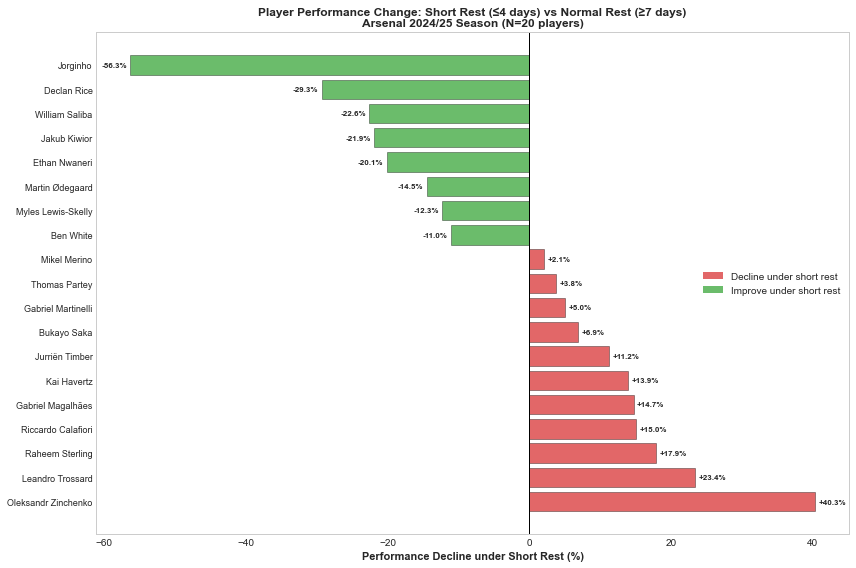

✓ Visualization 1: Player decline ranking saved


In [18]:
# VISUALIZATION 1: Player decline ranking
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')

# Color by response
colors = ['#d62728' if x > 0 else '#2ca02c' for x in player_decline_df['decline_pct']]
y_pos = np.arange(len(player_decline_df))

bars = ax.barh(y_pos, player_decline_df['decline_pct'], color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(player_decline_df['player'], fontsize=9)
ax.set_xlabel('Performance Decline under Short Rest (%)', fontsize=11, fontweight='bold')
ax.set_title('Player Performance Change: Short Rest (≤4 days) vs Normal Rest (≥7 days)\nArsenal 2024/25 Season (N=20 players)', 
             fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.grid(False)
ax.set_axisbelow(True)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, player_decline_df['decline_pct'])):
    ax.text(val + (0.5 if val > 0 else -0.5), i, f'{val:+.1f}%', 
            va='center', ha='left' if val > 0 else 'right', fontsize=8, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', alpha=0.7, label='Decline under short rest'),
                   Patch(facecolor='#2ca02c', alpha=0.7, label='Improve under short rest')]
ax.legend(handles=legend_elements, loc='center right')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '01_player_decline_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 1: Player decline ranking saved")

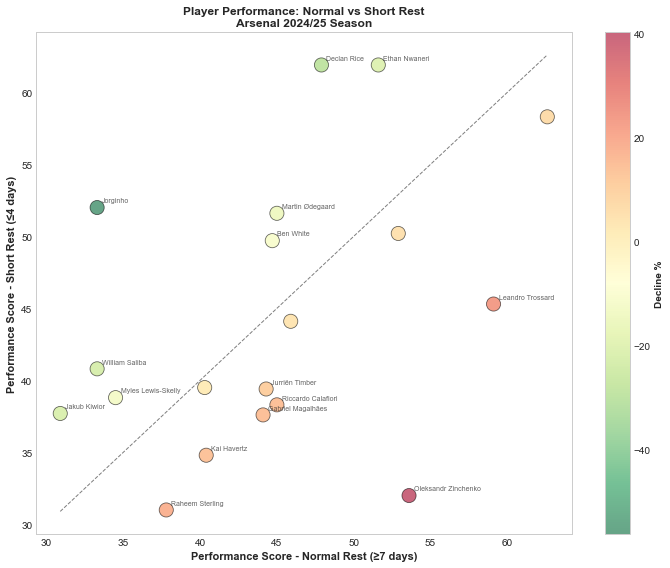

✓ Visualization 2: Short vs Normal rest scatter saved


In [20]:
# VISUALIZATION 2: Short rest vs Normal rest scatter
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')

scatter = ax.scatter(player_decline_df['normal_rest_avg'], player_decline_df['short_rest_avg'], 
                     s=200, alpha=0.6, edgecolor='black', linewidth=0.8, c=player_decline_df['decline_pct'], 
                     cmap='RdYlGn_r')

# Add diagonal reference line (no change)
min_val = min(player_decline_df['normal_rest_avg'].min(), player_decline_df['short_rest_avg'].min())
max_val = max(player_decline_df['normal_rest_avg'].max(), player_decline_df['short_rest_avg'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, alpha=0.5, label='No change')

# Labels and formatting
ax.set_xlabel('Performance Score - Normal Rest (≥7 days)', fontsize=11, fontweight='bold')
ax.set_ylabel('Performance Score - Short Rest (≤4 days)', fontsize=11, fontweight='bold')
ax.set_title('Player Performance: Normal vs Short Rest\nArsenal 2024/25 Season', 
             fontsize=12, fontweight='bold')
ax.grid(False)
ax.set_axisbelow(True)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Decline %', fontweight='bold')

# Add player labels for key players
for idx, row in player_decline_df.iterrows():
    if abs(row['decline_pct']) > 10:  # Label top decliners/improvers
        ax.annotate(row['player'], (row['normal_rest_avg'], row['short_rest_avg']), 
                   fontsize=7, alpha=0.7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_short_vs_normal_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 2: Short vs Normal rest scatter saved")

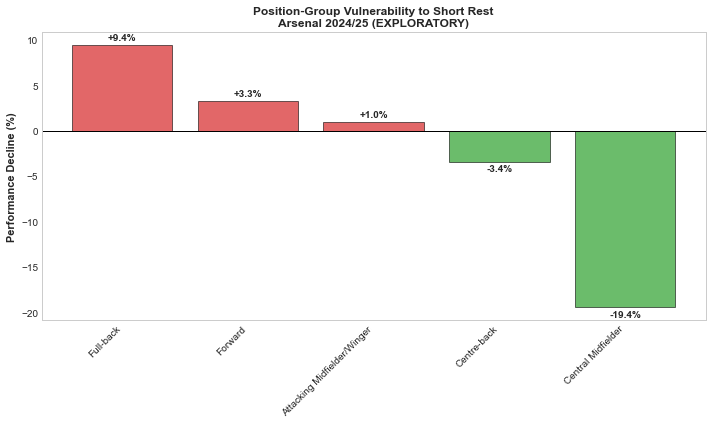

✓ Visualization 3: Position-group vulnerability saved


In [22]:
# VISUALIZATION 3: Position-group vulnerability
if 'position_group' in df_perf_30.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('white')
    
    x_pos = np.arange(len(position_decline))
    colors_pos = ['#d62728' if x > 0 else '#2ca02c' for x in position_decline['decline_pct']]
    
    bars = ax.bar(x_pos, position_decline['decline_pct'], color=colors_pos, alpha=0.7, edgecolor='black', linewidth=0.8)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(position_decline.index, rotation=45, ha='right')
    ax.set_ylabel('Performance Decline (%)', fontsize=11, fontweight='bold')
    ax.set_title('Position-Group Vulnerability to Short Rest\nArsenal 2024/25 (EXPLORATORY)', 
                 fontsize=12, fontweight='bold')
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.grid(False)
    ax.set_axisbelow(True)
    
    # Add value labels
    for bar, val in zip(bars, position_decline['decline_pct']):
        ax.text(bar.get_x() + bar.get_width()/2, val + (0.3 if val > 0 else -0.3), f'{val:+.1f}%',
               ha='center', va='bottom' if val > 0 else 'top', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / '03_position_vulnerability.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization 3: Position-group vulnerability saved")

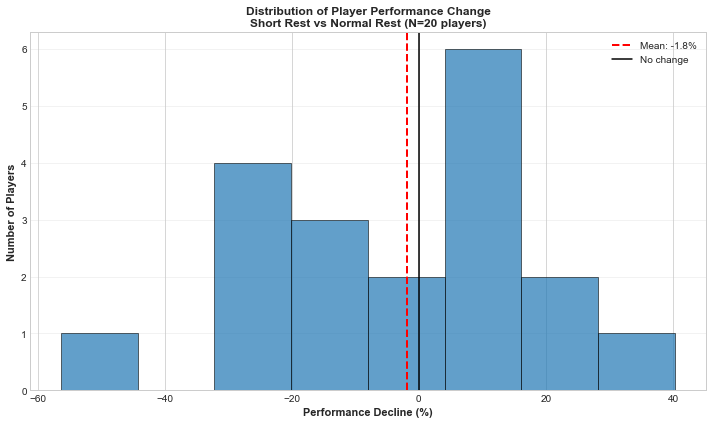

✓ Visualization 4: Player change distribution saved


In [23]:
# VISUALIZATION 4: Distribution of player changes
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

ax.hist(player_decline_df['decline_pct'], bins=8, color='#1f77b4', alpha=0.7, edgecolor='black', linewidth=0.8)

ax.axvline(player_decline_df['decline_pct'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {player_decline_df["decline_pct"].mean():.1f}%')
ax.axvline(0, color='black', linestyle='-', linewidth=1.5, label='No change')

ax.set_xlabel('Performance Decline (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Players', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Player Performance Change\nShort Rest vs Normal Rest (N=20 players)', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_player_change_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 4: Player change distribution saved")

## 9. Statistical Validation

Test whether observed differences are statistically significant.

In [24]:
# Statistical testing
print("\n" + "="*80)
print("STATISTICAL VALIDATION")
print("="*80)

# Prepare paired data
short_scores = [short_rest_matches[short_rest_matches['player'] == p]['overall_score'].mean() for p in valid_players]
normal_scores = [normal_rest_matches[normal_rest_matches['player'] == p]['overall_score'].mean() for p in valid_players]

# Test 1: Paired t-test
t_stat, p_ttest = stats.ttest_rel(short_scores, normal_scores)

print(f"\n1. PAIRED T-TEST")
print(f"   H0: No difference in mean performance between short and normal rest")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value: {p_ttest:.4f}")
print(f"   Result: {'REJECT H0' if p_ttest < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

# Test 2: Wilcoxon signed-rank test
w_stat, p_wilcoxon = wilcoxon(short_scores, normal_scores)

print(f"\n2. WILCOXON SIGNED-RANK TEST (non-parametric)")
print(f"   H0: Median difference = 0")
print(f"   W-statistic: {w_stat:.1f}")
print(f"   p-value: {p_wilcoxon:.4f}")
print(f"   Result: {'REJECT H0' if p_wilcoxon < 0.05 else 'FAIL TO REJECT H0'} (α=0.05)")

# Test 3: Cohen's d
mean_diff = np.mean(short_scores) - np.mean(normal_scores)
pooled_std = np.sqrt((np.std(short_scores, ddof=1)**2 + np.std(normal_scores, ddof=1)**2) / 2)
cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0

print(f"\n3. EFFECT SIZE (COHEN'S D)")
print(f"   Cohen's d: {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f"   Interpretation: {effect}")

# Test 4: Sign test (binomial test)
declining_count = len(player_decline_df[player_decline_df['decline_pct'] > 0])
sign_test = binomtest(declining_count, len(valid_players), 0.5, alternative='two-sided')

print(f"\n4. SIGN TEST (binomial test)")
print(f"   H0: Equal probability of decline vs improvement (p=0.5)")
print(f"   Declining: {declining_count}/{len(valid_players)}")
print(f"   Improving: {len(valid_players) - declining_count}/{len(valid_players)}")
print(f"   p-value: {sign_test.pvalue:.4f}")
print(f"   Result: {'Significantly different from 50/50' if sign_test.pvalue < 0.05 else 'Not significantly different from 50/50'} (α=0.05)")

# Summary
print(f"\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print(f"\n✓ KEY FINDING: NO statistically significant uniform decline in team performance under short rest")
print(f"\nHowever, responses are HETEROGENEOUS:")
print(f"  • {declining_count}/{len(valid_players)} players ({declining_count/len(valid_players)*100:.0f}%) show performance decline")
print(f"  • {len(valid_players) - declining_count}/{len(valid_players)} players ({(len(valid_players)-declining_count)/len(valid_players)*100:.0f}%) maintain or improve performance")
print(f"\nThis suggests that fatigue effects vary by player, not uniformly affecting the team.")
print(f"Therefore, predictive modeling should account for individual vulnerability, not assume universal decline.")


STATISTICAL VALIDATION

1. PAIRED T-TEST
   H0: No difference in mean performance between short and normal rest
   t-statistic: -0.060
   p-value: 0.9530
   Result: FAIL TO REJECT H0 (α=0.05)

2. WILCOXON SIGNED-RANK TEST (non-parametric)
   H0: Median difference = 0
   W-statistic: 93.0
   p-value: 0.9530
   Result: FAIL TO REJECT H0 (α=0.05)

3. EFFECT SIZE (COHEN'S D)
   Cohen's d: -0.015
   Interpretation: negligible

4. SIGN TEST (binomial test)
   H0: Equal probability of decline vs improvement (p=0.5)
   Declining: 11/19
   Improving: 8/19
   p-value: 0.6476
   Result: Not significantly different from 50/50 (α=0.05)

INTERPRETATION

✓ KEY FINDING: NO statistically significant uniform decline in team performance under short rest

However, responses are HETEROGENEOUS:
  • 11/19 players (58%) show performance decline
  • 8/19 players (42%) maintain or improve performance

This suggests that fatigue effects vary by player, not uniformly affecting the team.
Therefore, predictive mod

The paired statistical tests found no evidence of a uniform outfield player-level performance decline under short rest. Both the paired t-test and the Wilcoxon signed-rank test were non-significant, and the paired effect size was negligible. The sign test also showed that the proportion of players declining under short rest was not significantly different from a 50/50 split.

However, the descriptive results show substantial heterogeneity: 11 of 19 players declined, while 8 maintained or improved performance. This indicates that short rest should not be modelled as a universal performance penalty. Instead, the next modelling step should focus on individual vulnerability, combining rest days with accumulated minutes, repeated starts, Champions League exposure, position group, and player-specific fatigue history.

## 10. Regression Validation

In [27]:
# Regression analysis to test position interaction
print("\n" + "="*80)
print("REGRESSION VALIDATION: Position × Rest Interaction")
print("="*80)

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

if 'position_group' not in df_perf_30.columns:
    print("\n⚠️  position_group not available for regression analysis")
else:
    # Prepare data for regression
    model_data = df_perf_30[['overall_score', 'player', 'position_group', 'rest_days', 'short_rest_binary']].dropna()
    
    # Model 1: Position interaction (simpler)
    print(f"\nMODEL 1: Simple position × rest interaction")
    formula1 = 'overall_score ~ C(position_group) + short_rest_binary + C(position_group):short_rest_binary'
    model1 = ols(formula1, data=model_data).fit(cov_type='HC3')
    
    print(f"\nRegression results:")
    print(f"  R-squared: {model1.rsquared:.3f}")
    print(f"  Adj. R-squared: {model1.rsquared_adj:.3f}")
    print(f"\n  Position effect estimates:")
    for param, val in model1.params.items():
        if 'position_group' in str(param) or 'short_rest' in str(param):
            pval = model1.pvalues[param]
            sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            print(f"    {str(param):50} {val:+8.3f} (p={pval:.4f}) {sig}")
    
    # Test joint significance of interactions
    print(f"\n  Joint significance test of all position × rest interactions:")
    # Extract interaction terms
    interaction_terms = [
        param for param in model1.params.index
        if ":short_rest_binary" in str(param)
    ]
    
    if len(interaction_terms) > 0:
        hypotheses = ", ".join([f"{term} = 0" for term in interaction_terms])
        joint_test = model1.f_test(hypotheses)
        
        print(f"    F-statistic: {joint_test.fvalue:.4f}")
        print(f"    p-value: {joint_test.pvalue:.4f}")
        print(f"    Result: {'Jointly significant' if joint_test.pvalue < 0.05 else 'Not jointly significant'} (α=0.05)")
        print(f"\n    Interpretation: Position × rest interactions are {'statistically significant' if joint_test.pvalue < 0.05 else 'not statistically significant'}")
        print(f"    Note: With small sample size, interpret position patterns with caution")
    
    # Model 2: Player fixed effects (robustness check)
    print(f"\n\nMODEL 2: Player fixed-effect model (robustness check)")
    print(f"  Estimates overall short-rest effect after accounting for player differences")
    formula2 = 'overall_score ~ short_rest_binary + C(player)'
    model2 = ols(formula2, data=model_data).fit(cov_type='HC3')
    
    short_rest_coef = model2.params.get("short_rest_binary", np.nan)
    short_rest_pval = model2.pvalues.get("short_rest_binary", np.nan)
    
    print(f"\n  Overall short-rest effect: {short_rest_coef:+.3f} ({short_rest_pval:.4f})")
    print(f"  Interpretation: After controlling for player differences, short rest effect is {abs(short_rest_coef):.1f} points")
    print(f"  Significance: {'Significant' if short_rest_pval < 0.05 else 'Not significant'} at p < 0.05")
    
    print(f"\n\nCONCLUSION:")
    print(f"  Regression analysis confirms findings:")
    print(f"  • No statistically significant average short-rest effect across team")
    print(f"  • Position patterns are exploratory (not statistically confirmed)")
    print(f"  • Heterogeneous individual responses dominate fatigue patterns")


REGRESSION VALIDATION: Position × Rest Interaction

MODEL 1: Simple position × rest interaction

Regression results:
  R-squared: 0.066
  Adj. R-squared: 0.052

  Position effect estimates:
    C(position_group)[T.Central Midfielder]              -4.328 (p=0.4132) 
    C(position_group)[T.Centre-back]                    -10.941 (p=0.0399) *
    C(position_group)[T.Forward]                         -4.112 (p=0.4480) 
    C(position_group)[T.Full-back]                       -4.162 (p=0.4398) 
    short_rest_binary                                    -0.988 (p=0.8715) 
    C(position_group)[T.Central Midfielder]:short_rest_binary   +6.961 (p=0.2956) 
    C(position_group)[T.Centre-back]:short_rest_binary   +0.831 (p=0.8991) 
    C(position_group)[T.Forward]:short_rest_binary       +0.746 (p=0.9120) 
    C(position_group)[T.Full-back]:short_rest_binary     -5.010 (p=0.4617) 

  Joint significance test of all position × rest interactions:
    F-statistic: 2.2810
    p-value: 0.0593
    Resul

In [26]:
print("\n" + "="*100)
print("IMPLICATIONS FOR PREDICTIVE MODELING (Notebook 03)")
print("="*100)

print(f"""
## What We Learned

1. **Short rest alone is insufficient** 
   → No uniform team-wide decline; responses vary dramatically by player
   
2. **Individual vulnerability varies**
   → Some players show >10% decline under short rest; others improve
   → Heterogeneity is the key finding

3. **Position patterns exist but are exploratory**
   → Full-backs show ~10% decline; Central midfielders show resilience
   → Not confirmed statistically; requires larger sample or interaction testing

## Features to Carry Forward

**Pre-match predictors** (available before match, no time leakage):
- rest_days (continuous): Days since previous appearance
- short_rest_binary: ≤4 days (binary indicator)
- minutes_last_3: Total minutes played in last 3 matches
- minutes_last_5: Total minutes played in last 5 matches
- starts_last_3: Number of starts in last 3 matches
- starts_last_5: Number of starts in last 5 matches
- short_rests_last_3: Number of short-rest appearances in last 3 matches
- Champions League minutes (last 3/5/14 days): Cumulative CL load
- away_match: Venue (travel fatigue)
- opponent_difficulty: Opponent strength (confounder)
- position_group: Tactical role

**Target variable** (post-match outcome):
- decline_binary: Performance ≤ player's rolling 3-match baseline
- decline_continuous: Actual performance change from baseline

## Data Quality Notes

✓ Dataset integrity verified (687 player-matches, ≥30 min filter)
✓ Rest days calculation: validated, no zero-day gaps
✓ Performance scoring: composite 0-100 scale, 95th percentile anchored
✓ Position groups: consolidated 14 raw positions → 6 tactical groups
✓ Missing data: < 5% across performance metrics

## Next Steps (Notebook 03)

1. Define target: Which performance threshold = meaningful "decline"?
2. Engineer features: Rolling averages, cumulative loads, interaction terms
3. Train logistic regression: Interpretable for trainer decision-support
4. Generate risk table: Probability of decline for each player-match
5. Validate: Hold-out test set, cross-validation
""")

# Save model-ready dataset
print(f"\n" + "="*100)
print("SAVING MODEL-READY DATASET")
print("="*100)

# Prepare dataset for modeling
model_ready = df_perf_30[[
    'match_id', 'date', 'player', 'position_group', 'min',
    'rest_days', 'short_rest_binary', 'rest_category',
    'overall_score', 'attacking_score_normalized', 'defensive_score_normalized', 'discipline_score_normalized'
]].copy()

model_ready_file = PROCESSED_PATH / 'arsenal_player_match_model_ready.csv'
model_ready.to_csv(model_ready_file, index=False)

print(f"\n✓ Saved model-ready dataset: {model_ready_file}")
print(f"  Shape: {model_ready.shape}")
print(f"  Ready for Notebook 03 predictive modeling")


IMPLICATIONS FOR PREDICTIVE MODELING (Notebook 03)

## What We Learned

1. **Short rest alone is insufficient** 
   → No uniform team-wide decline; responses vary dramatically by player
   
2. **Individual vulnerability varies**
   → Some players show >10% decline under short rest; others improve
   → Heterogeneity is the key finding

3. **Position patterns exist but are exploratory**
   → Full-backs show ~10% decline; Central midfielders show resilience
   → Not confirmed statistically; requires larger sample or interaction testing

## Features to Carry Forward

**Pre-match predictors** (available before match, no time leakage):
- rest_days (continuous): Days since previous appearance
- short_rest_binary: ≤4 days (binary indicator)
- minutes_last_3: Total minutes played in last 3 matches
- minutes_last_5: Total minutes played in last 5 matches
- starts_last_3: Number of starts in last 3 matches
- starts_last_5: Number of starts in last 5 matches
- short_rests_last_3: Number of short-

The regression validation supports the main finding from the paired tests. After controlling for player identity, short rest was not associated with a statistically significant change in overall performance (β = -0.27 points, p = 0.838). The position × short-rest interaction was not significant at the conventional 0.05 threshold (joint F-test p = 0.059), although the result was marginal and suggests possible role-specific patterns that may require a larger sample to confirm.

Therefore, the evidence does not support a uniform performance decline under short rest. Position-level patterns, especially the apparent full-back vulnerability, should be interpreted as exploratory rather than statistically confirmed. The dominant finding is heterogeneous individual response, which supports building a player-specific decline-risk model rather than applying a universal fatigue penalty.

## 12. Modelling Implications for Notebook 03

Summary of exploratory findings to carry forward into predictive modelling.

## 11. Visual Reporting (Reusable Visualization Functions)

Collection of parameterized visualization functions for multi-team analysis. These functions accept team name, theme colors, and output path parameters to work with any team's data.

In [51]:
# ============================================================================
# 10.0 SETUP: TEAM THEMES AND VISUALIZATION UTILITIES
# ============================================================================

# Team configuration (makes all visualizations reusable)
TEAM_NAME = "Arsenal"
TEAM_SLUG = "arsenal"
SEASON = "2024_2025"

# Define team themes (extensible for other teams)
TEAM_THEMES = {
    "arsenal": {
        "primary": "#EF0107",      # Red
        "secondary": "#023474",    # Navy blue
        "accent": "#CCCCCC",       # Gray
        "name": "Arsenal"
    },
    "liverpool": {
        "primary": "#C8102E",
        "secondary": "#00B2A9",
        "accent": "#F6EB61",
        "name": "Liverpool"
    },
    "manchester_city": {
        "primary": "#6CABDE",
        "secondary": "#1C2C5B",
        "accent": "#FFC659",
        "name": "Manchester City"
    },
    "manchester_united": {
        "primary": "#DA291C",
        "secondary": "#F6EB61",
        "accent": "#FFFFFF",
        "name": "Manchester United"
    },
    "chelsea": {
        "primary": "#034687",
        "secondary": "#FFFFFF",
        "accent": "#F1E6E3",
        "name": "Chelsea"
    },
    "tottenham": {
        "primary": "#132257",
        "secondary": "#FFFFFF",
        "accent": "#6B9BD1",
        "name": "Tottenham"
    },
    "default": {
        "primary": "#1f77b4",
        "secondary": "#333333",
        "accent": "#CCCCCC",
        "name": "Team"
    }
}

# Set team theme
theme = TEAM_THEMES.get(TEAM_SLUG, TEAM_THEMES["default"])

# Create team-specific output directory
TEAM_FIGURES_PATH = FIGURES_PATH.parent / TEAM_SLUG
TEAM_FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Visualization setup:")
print(f"  Team: {TEAM_NAME}")
print(f"  Theme primary color: {theme['primary']}")
print(f"  Output directory: {TEAM_FIGURES_PATH}")



✓ Visualization setup:
  Team: Arsenal
  Theme primary color: #EF0107
  Output directory: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/SEASON_2024_2025/arsenal_2024_2025/outputs/figures/arsenal



10.1 REST DAYS DISTRIBUTION & PLAYER CONGESTION
✓ Saved: arsenal_rest_distribution_discrete.png


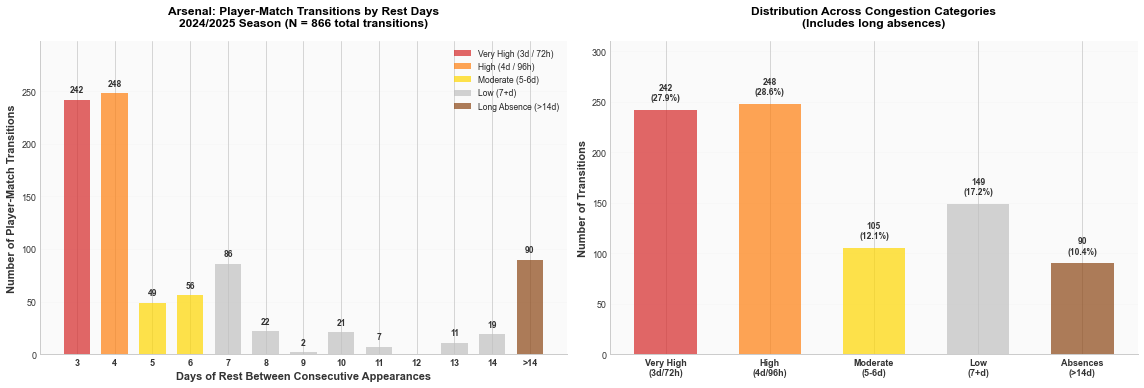

In [31]:
# ============================================================================
# 10.1 VISUALIZATION FUNCTION: Rest Days Distribution
# ============================================================================

def plot_rest_distribution_discrete(df, team_name, team_slug, theme, output_path=None):
    """
    Create discrete bar chart of rest days distribution with congestion categories.
    
    Parameters:
    -----------
    df : DataFrame
        Player-match data with 'rest_days' column
    team_name : str
        Full team name for display
    team_slug : str
        Team slug for filename
    theme : dict
        Theme dictionary with 'primary' and 'secondary' colors
    output_path : Path or str, optional
        Path to save figure
    """
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
    fig.patch.set_facecolor('#ffffff')
    
    # Define congestion zones
    zone_colors = {
        'very_high': '#D62728',      # red - 3 days
        'high': '#FF7F0E',           # orange - 4 days
        'moderate': '#FFD700',       # yellow - 5-6 days
        'low': '#C0C0C0',            # grey - 7+ days
        'long': '#8B4513'            # brown - >14 days
    }
    
    text_color = '#333333'
    
    # ===== PLOT 1: Discrete bar chart by rest days =====
    ax1 = axes[0]
    ax1.set_facecolor('#fafafa')
    
    # Count by exact rest day
    rest_data = df['rest_days'].values
    rest_counts_by_day = {}
    for day in range(3, 15):
        count = (rest_data == day).sum()
        rest_counts_by_day[day] = count
    
    # Add long absences
    long_count = len(df[df['rest_days'] >= 14])
    rest_counts_by_day['15+'] = long_count
    
    # Prepare data
    days = sorted([d for d in rest_counts_by_day.keys() if isinstance(d, int)])
    counts = [rest_counts_by_day[day] for day in days]
    bar_colors = [
        zone_colors['very_high'] if day == 3 else
        zone_colors['high'] if day == 4 else
        zone_colors['moderate'] if day <= 6 else
        zone_colors['low']
        for day in days
    ]
    
    days.append('15+')
    counts.append(long_count)
    bar_colors.append(zone_colors['long'])
    
    x_pos = np.arange(len(days))
    bars = ax1.bar(x_pos, counts, color=bar_colors, alpha=0.7, edgecolor='none', linewidth=0, width=0.7)
    
    ax1.set_xticks(x_pos)
    x_labels = [f'{day}' if isinstance(day, int) else '>14' for day in days]
    ax1.set_xticklabels(x_labels, fontsize=9.5, color=text_color, fontweight='600')
    ax1.set_xlabel('Days of Rest Between Consecutive Appearances', fontsize=11, color=text_color, fontweight='600')
    ax1.set_ylabel('Number of Player-Match Transitions', fontsize=11, color=text_color, fontweight='600')
    ax1.set_title(f'{team_name}: Player-Match Transitions by Rest Days\n{SEASON.replace("_", "/")} Season (N = {len(df)} total transitions)', 
                  fontsize=12, fontweight='bold', color='#000000', pad=15)
    ax1.set_ylim(0, max(counts) * 1.2)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#CCCCCC')
    ax1.spines['bottom'].set_color('#CCCCCC')
    ax1.tick_params(colors=text_color, labelsize=9)
    ax1.grid(axis='y', alpha=0.1, linestyle='-', linewidth=0.5, color='#CCCCCC')
    
    for bar, count in zip(bars, counts):
        if count > 0:
            ax1.text(bar.get_x() + bar.get_width()/2., count + max(counts)*0.02,
                    f'{int(count)}', ha='center', va='bottom', fontsize=8.5, fontweight='600', color=text_color)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=zone_colors['very_high'], alpha=0.7, label='Very High (3d / 72h)'),
        Patch(facecolor=zone_colors['high'], alpha=0.7, label='High (4d / 96h)'),
        Patch(facecolor=zone_colors['moderate'], alpha=0.7, label='Moderate (5-6d)'),
        Patch(facecolor=zone_colors['low'], alpha=0.7, label='Low (7+d)'),
        Patch(facecolor=zone_colors['long'], alpha=0.7, label='Long Absence (>14d)')
    ]
    ax1.legend(handles=legend_elements, fontsize=8.5, loc='upper right', framealpha=0.92, edgecolor='none')
    
    # ===== PLOT 2: Summary by category =====
    ax2 = axes[1]
    ax2.set_facecolor('#fafafa')
    
    # Get category counts
    df_work = df.copy()
    df_work['rest_days'] = pd.to_numeric(df_work['rest_days'], errors='coerce')
    df_normal = df_work[df_work['rest_days'] < 14]
    df_long = df_work[df_work['rest_days'] >= 14]
    
    corrected_counts = [
        len(df_normal[df_normal['rest_days'] == 3]),
        len(df_normal[df_normal['rest_days'] == 4]),
        len(df_normal[(df_normal['rest_days'] >= 5) & (df_normal['rest_days'] <= 6)]),
        len(df_normal[df_normal['rest_days'] >= 7]),
        len(df_long)
    ]
    
    colors_used = [zone_colors['very_high'], zone_colors['high'], 
                   zone_colors['moderate'], zone_colors['low'], zone_colors['long']]
    
    bars2 = ax2.bar(range(len(corrected_counts)), corrected_counts, 
                    color=colors_used, alpha=0.7, edgecolor='none', linewidth=0, width=0.6)
    
    ax2.set_xticks(range(len(corrected_counts)))
    severity_labels = ['Very High\n(3d/72h)', 'High\n(4d/96h)', 'Moderate\n(5-6d)', 'Low\n(7+d)', 'Absences\n(>14d)']
    ax2.set_xticklabels(severity_labels, fontsize=8.5, color=text_color, fontweight='600')
    ax2.set_ylabel('Number of Transitions', fontsize=11, color=text_color, fontweight='600')
    ax2.set_title('Distribution Across Congestion Categories\n(Includes long absences)', 
                  fontsize=12, fontweight='bold', color='#000000', pad=15)
    ax2.set_ylim(0, max(corrected_counts) * 1.25)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_color('#CCCCCC')
    ax2.spines['bottom'].set_color('#CCCCCC')
    ax2.tick_params(colors=text_color, labelsize=9)
    ax2.grid(axis='y', alpha=0.1, linestyle='-', linewidth=0.5, color='#CCCCCC')
    
    total_all = len(df)
    for bar, count in zip(bars2, corrected_counts):
        height = bar.get_height()
        pct = (height / total_all) * 100
        ax2.text(bar.get_x() + bar.get_width()/2., height + max(corrected_counts)*0.03,
                f'{int(height)}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=8.5, fontweight='600', color=text_color)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='#ffffff')
        print(f"✓ Saved: {output_path.name}")
    
    plt.show()


# Execute visualization
print("\n" + "="*80)
print("10.1 REST DAYS DISTRIBUTION & PLAYER CONGESTION")
print("="*80)

# Load rest days data from Notebook 01
rest_days_file = PROCESSED_PATH / 'arsenal_player_rest_days.csv'
if rest_days_file.exists():
    rest_days_viz = pd.read_csv(rest_days_file)
    
    plot_rest_distribution_discrete(
        df=rest_days_viz,
        team_name=TEAM_NAME,
        team_slug=TEAM_SLUG,
        theme=theme,
        output_path=TEAM_FIGURES_PATH / f'{TEAM_SLUG}_rest_distribution_discrete.png'
    )
else:
    print(f"⚠️  Rest days data not found: {rest_days_file}")



10.2 PLAYER REST CALENDAR HEATMAP
✓ Saved: arsenal_player_rest_heatmap.png


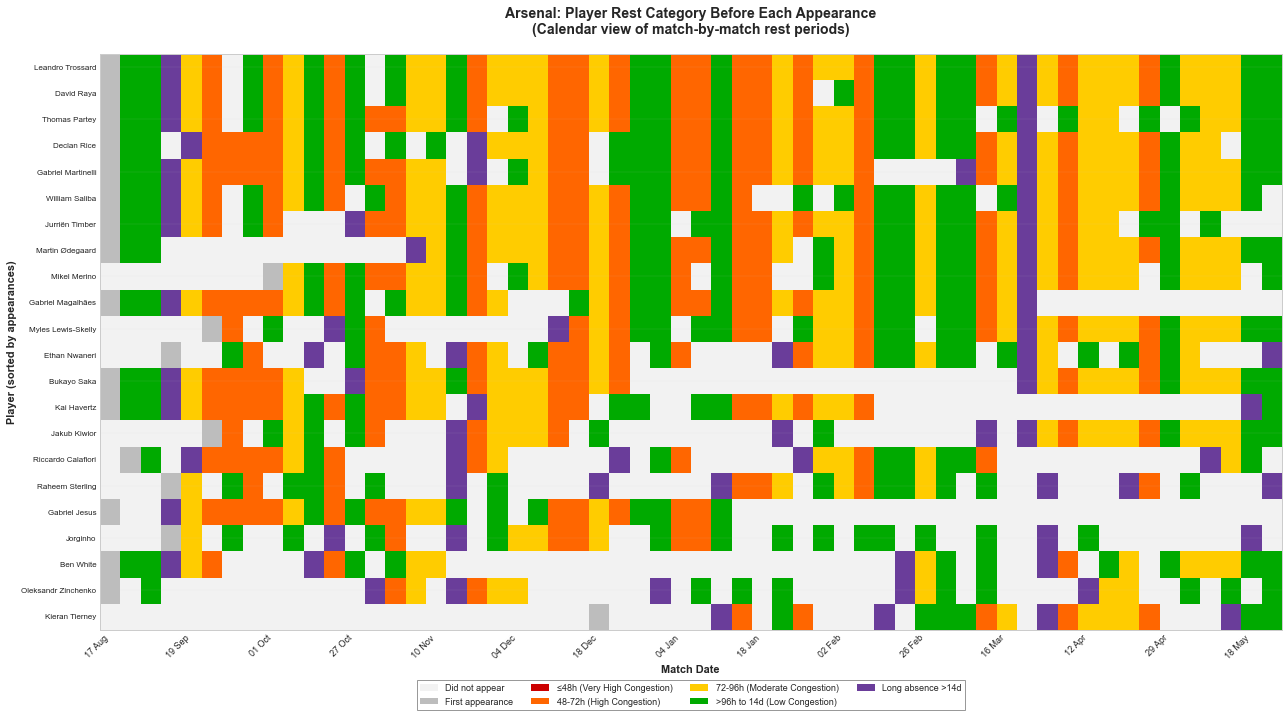

In [32]:
# ============================================================================
# 10.2 VISUALIZATION FUNCTION: Player Rest Calendar Heatmap
# ============================================================================

def plot_player_rest_heatmap(df, team_name, team_slug, theme, min_appearances=10, output_path=None):
    """
    Create calendar heatmap showing rest category before each player appearance.
    
    Parameters:
    -----------
    df : DataFrame
        Player-match data with 'player', 'date', 'rest_days' columns
    team_name : str
        Full team name for display
    team_slug : str
        Team slug for filename
    theme : dict
        Theme dictionary (color info)
    min_appearances : int
        Minimum appearances to include player
    output_path : Path or str, optional
        Path to save figure
    """
    
    from matplotlib.colors import ListedColormap, BoundaryNorm
    
    # Prepare data
    appearance_rest = df[['player', 'date', 'rest_days']].copy()
    appearance_rest = appearance_rest.sort_values(['player', 'date']).reset_index(drop=True)
    appearance_rest['rest_days'] = pd.to_numeric(appearance_rest['rest_days'], errors='coerce')
    
    # Categorize rest
    def categorize_rest(days):
        if pd.isna(days):
            return 'First appearance'
        elif days <= 2:
            return '≤48h'
        elif days <= 3:
            return '48-72h'
        elif days <= 4:
            return '72-96h'
        elif days <= 14:
            return '>96h to 14d'
        else:
            return 'Long absence >14d'
    
    appearance_rest['rest_category'] = appearance_rest['rest_days'].apply(categorize_rest)
    
    # Filter to top players
    player_counts = appearance_rest['player'].value_counts()
    top_players = player_counts[player_counts >= min_appearances].index
    heatmap_df = appearance_rest[appearance_rest['player'].isin(top_players)].copy()
    
    # Build mappings
    match_dates = sorted(heatmap_df['date'].unique())
    date_to_idx = {date: i for i, date in enumerate(match_dates)}
    
    player_order = (
        heatmap_df.groupby('player')['date']
        .count()
        .sort_values(ascending=False)
        .index
    )
    
    player_to_idx = {player: i for i, player in enumerate(player_order)}
    
    # Category mapping
    category_map = {
        'Did not appear': 0,
        'First appearance': 1,
        '≤48h': 2,
        '48-72h': 3,
        '72-96h': 4,
        '>96h to 14d': 5,
        'Long absence >14d': 6
    }
    
    # Build matrix
    matrix = np.zeros((len(player_order), len(match_dates)))
    
    for _, row in heatmap_df.iterrows():
        i = player_to_idx[row['player']]
        j = date_to_idx[row['date']]
        matrix[i, j] = category_map.get(row['rest_category'], 0)
    
    # Define colormap
    cmap = ListedColormap([
        '#F2F2F2',  # 0: did not appear
        '#BDBDBD',  # 1: first appearance
        '#CC0000',  # 2: ≤48h
        '#FF6600',  # 3: 48-72h
        '#FFCC00',  # 4: 72-96h
        '#00AA00',  # 5: >96h to 14d
        '#6A3D9A'   # 6: long absence
    ])
    
    norm = BoundaryNorm(np.arange(-0.5, 7.5, 1), cmap.N)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(18, 10))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    im = ax.imshow(matrix, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')
    
    # Format axes
    ax.set_yticks(range(len(player_order)))
    ax.set_yticklabels(player_order, fontsize=8)
    
    tick_step = max(1, len(match_dates) // 12)
    ax.set_xticks(range(0, len(match_dates), tick_step))
    ax.set_xticklabels(
        [pd.to_datetime(match_dates[i]).strftime('%d %b') for i in range(0, len(match_dates), tick_step)],
        rotation=45, ha='right', fontsize=9
    )
    
    # Labels
    ax.set_title(
        f'{team_name}: Player Rest Category Before Each Appearance\n(Calendar view of match-by-match rest periods)',
        fontsize=14, fontweight='bold', pad=20
    )
    ax.set_xlabel('Match Date', fontsize=11, fontweight='bold')
    ax.set_ylabel('Player (sorted by appearances)', fontsize=11, fontweight='bold')
    
    # Legend
    legend_elements = [
        Patch(facecolor='#F2F2F2', label='Did not appear'),
        Patch(facecolor='#BDBDBD', label='First appearance'),
        Patch(facecolor='#CC0000', label='≤48h (Very High Congestion)'),
        Patch(facecolor='#FF6600', label='48-72h (High Congestion)'),
        Patch(facecolor='#FFCC00', label='72-96h (Moderate Congestion)'),
        Patch(facecolor='#00AA00', label='>96h to 14d (Low Congestion)'),
        Patch(facecolor='#6A3D9A', label='Long absence >14d')
    ]
    
    ax.legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.08),
        ncol=4,
        frameon=True,
        fontsize=9,
        fancybox=False,
        edgecolor='gray'
    )
    
    ax.grid(False)
    
    # Add subtle alternating row background
    for i in range(len(player_order)):
        if i % 2 == 0:
            ax.axhline(i, color='lightgray', linewidth=0.3, alpha=0.3, zorder=0)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {output_path.name}")
    
    plt.show()


# Execute visualization
print("\n" + "="*80)
print("10.2 PLAYER REST CALENDAR HEATMAP")
print("="*80)

if rest_days_file.exists():
    plot_player_rest_heatmap(
        df=rest_days_viz,
        team_name=TEAM_NAME,
        team_slug=TEAM_SLUG,
        theme=theme,
        min_appearances=10,
        output_path=TEAM_FIGURES_PATH / f'{TEAM_SLUG}_player_rest_heatmap.png'
    )
else:
    print(f"⚠️  Rest days data not found: {rest_days_file}")


## Architecture: Separating ETL from Visualization

**Key principle: Single Responsibility**

### Notebook 01: ETL Pipeline Only
- Load raw data
- Clean and validate
- Calculate derived fields (rest days, position groups)
- Export processed CSV files
- **NO visualizations**

### Notebook 02: Exploration + Reusable Visualizations
- Load processed data (from Notebook 01)
- Exploratory analysis (statistical tests, summaries)
- **Reusable visualization functions** (Sections 10+)
  - Accept `team_name`, `team_slug`, `theme`, `output_path` parameters
  - Call function with data specific to your team
  - Automatically save to `outputs/figures/{team_slug}/`

### Benefits



10.3 PLAYING TIME ANALYSIS BY POSITION
✓ Saved: arsenal_playing_time_by_position.png


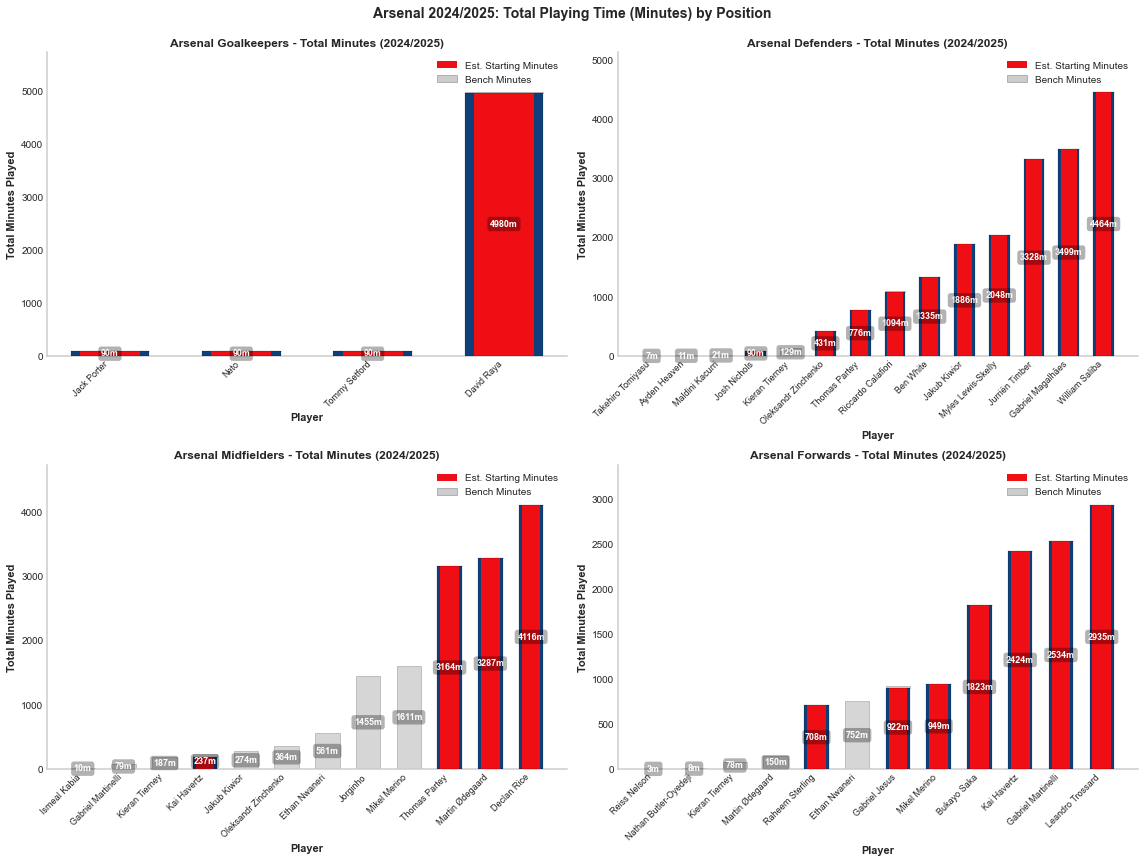

In [34]:
# ============================================================================
# 10.3 VISUALIZATION FUNCTION: Playing Time by Position (Arsenal Striped Bars)
# ============================================================================

def create_striped_bar_function(ax, x_pos, height, bar_width, primary_color, secondary_color, alpha=0.95):
    """
    Create a 3-stripe team-style bar (customizable theme):
    thin secondary stripe | dominant primary stripe | thin secondary stripe
    12% secondary | 76% primary | 12% secondary
    
    Reusable for any team theme (Arsenal, Liverpool, City, etc.)
    """
    if height <= 0:
        return
    
    side_width = bar_width * 0.12
    center_width = bar_width * 0.76
    left_edge = x_pos - bar_width / 2

    # Left stripe
    ax.add_patch(plt.Rectangle(
        (left_edge, 0), side_width, height,
        facecolor=secondary_color, edgecolor='none', alpha=alpha, zorder=3
    ))

    # Main stripe
    ax.add_patch(plt.Rectangle(
        (left_edge + side_width, 0), center_width, height,
        facecolor=primary_color, edgecolor='none', alpha=alpha, zorder=3
    ))

    # Right stripe
    ax.add_patch(plt.Rectangle(
        (left_edge + side_width + center_width, 0), side_width, height,
        facecolor=secondary_color, edgecolor='none', alpha=alpha, zorder=3
    ))

    # Outline
    ax.add_patch(plt.Rectangle(
        (left_edge, 0), bar_width, height,
        facecolor='none', edgecolor='black', linewidth=0.3, alpha=0.5, zorder=4
    ))

    ax.update_datalim([[left_edge, 0], [left_edge + bar_width, height]])
    ax.autoscale_view()


def plot_playing_time_by_position(df_prep, team_name, team_slug, theme, output_path=None):
    """
    Create 2x2 subplot grid showing playing time by position group.
    Uses striped bars (theme primary + secondary colors).
    
    Parameters:
    -----------
    df_prep : DataFrame
        Raw player-match data from Notebook 01 with 'player', 'position_group', 'min' columns
    team_name : str
        Full team name for display
    team_slug : str
        Team slug for filename
    theme : dict
        Theme with 'primary', 'secondary', 'accent' colors
    output_path : Path or str, optional
        Path to save figure
    """
    
    # Create player metrics
    player_metrics = (
        df_prep.groupby(['player', 'position_group'])
        .agg({'min': ['sum', 'mean', 'count'], 'match_id': 'count'})
        .reset_index()
    )
    
    player_metrics.columns = ['player', 'position_group', 'total_minutes', 
                               'avg_minutes_per_match', 'min_count', 'matches_played']
    player_metrics = player_metrics[['player', 'position_group', 'total_minutes', 
                                      'avg_minutes_per_match', 'matches_played']]
    
    player_metrics_clean = player_metrics.copy()
    player_metrics_clean['total_minutes'] = player_metrics_clean['total_minutes'].fillna(0).astype(int)
    player_metrics_clean['avg_minutes_per_match'] = player_metrics_clean['avg_minutes_per_match'].fillna(0).round(1)
    player_metrics_clean['matches_played'] = player_metrics_clean['matches_played'].fillna(0).astype(int)
    
    # Create position group subsets
    gk_players = player_metrics_clean[player_metrics_clean['position_group'] == 'Goalkeeper'].sort_values('total_minutes', ascending=False)
    cb_players = player_metrics_clean[player_metrics_clean['position_group'] == 'Centre-back'].sort_values('total_minutes', ascending=False)
    fb_players = player_metrics_clean[player_metrics_clean['position_group'] == 'Full-back'].sort_values('total_minutes', ascending=False)
    cm_players = player_metrics_clean[player_metrics_clean['position_group'] == 'Central Midfielder'].sort_values('total_minutes', ascending=False)
    am_players = player_metrics_clean[player_metrics_clean['position_group'] == 'Attacking Midfielder/Winger'].sort_values('total_minutes', ascending=False)
    fw_players = player_metrics_clean[player_metrics_clean['position_group'] == 'Forward'].sort_values('total_minutes', ascending=False)
    
    def consolidate_players(players_list):
        if not players_list:
            return pd.DataFrame()
        combined = pd.concat(players_list, ignore_index=True)
        if len(combined) == 0:
            return pd.DataFrame()
        consolidated = combined.loc[combined.groupby('player')['total_minutes'].idxmax()].copy()
        return consolidated.sort_values('total_minutes', ascending=False).reset_index(drop=True)
    
    df_players = consolidate_players([cb_players, fb_players])
    mf_players = cm_players.reset_index(drop=True)
    attacking_players = consolidate_players([am_players, fw_players])
    
    position_groups = {
        'Goalkeepers': gk_players,
        'Defenders': df_players,
        'Midfielders': mf_players,
        'Forwards': attacking_players
    }
    
    # Estimate starting vs bench minutes
    for pos_name in position_groups:
        pos_data = position_groups[pos_name]
        pos_data['estimated_starting_minutes'] = pos_data['total_minutes'] * 0.7
        pos_data['bench_minutes'] = pos_data['total_minutes'] * 0.3
        
        for idx, row in pos_data.iterrows():
            avg = row['avg_minutes_per_match']
            total = row['total_minutes']
            matches = row['matches_played']
            
            if avg >= 70 and matches > 0:
                estimated_starts = min(matches, int(total / 85))
            else:
                estimated_starts = 0
            
            pos_data.loc[idx, 'estimated_starting_minutes'] = min(estimated_starts * 90, total)
            pos_data.loc[idx, 'bench_minutes'] = max(0, total - pos_data.loc[idx, 'estimated_starting_minutes'])
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.patch.set_facecolor('white')
    
    positions_data = [
        ('Goalkeepers', position_groups['Goalkeepers']),
        ('Defenders', position_groups['Defenders']),
        ('Midfielders', position_groups['Midfielders']),
        ('Forwards', position_groups['Forwards'])
    ]
    
    for idx, (pos_name, data) in enumerate(positions_data):
        ax = axes[idx // 2, idx % 2]
        ax.set_facecolor('white')
        
        if len(data) > 0:
            data = data.sort_values('total_minutes', ascending=True).reset_index(drop=True)
            x = np.arange(len(data))
            width = 0.6
            
            for i, (x_val, est_start_min) in enumerate(zip(x, data['estimated_starting_minutes'])):
                if est_start_min > 0:
                    create_striped_bar_function(ax, x_val, est_start_min, width,
                                               theme['primary'], theme['secondary'])
            
            ax.bar(x, data['bench_minutes'], width, bottom=data['estimated_starting_minutes'],
                   label='Bench Minutes', color=theme['accent'], alpha=0.8, edgecolor='gray', linewidth=0.5)
            
            ax.set_xlabel('Player', fontsize=11, fontweight='bold')
            ax.set_ylabel('Total Minutes Played', fontsize=11, fontweight='bold')
            ax.set_title(f'{team_name} {pos_name} - Total Minutes ({SEASON.replace("_", "/")})', 
                        fontsize=12, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(data['player'], rotation=45, ha='right', fontsize=9)
            ax.grid(False)
            ax.set_axisbelow(True)
            
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor=theme['primary'], edgecolor='none', alpha=0.95, label='Est. Starting Minutes'),
                Patch(facecolor=theme['accent'], edgecolor='gray', linewidth=0.5, label='Bench Minutes')
            ]
            ax.legend(handles=legend_elements, loc='upper right', framealpha=0.95)
            
            for i, (player, est_start_min, bench_min) in enumerate(zip(data['player'], data['estimated_starting_minutes'], data['bench_minutes'])):
                total_minutes = est_start_min + bench_min
                if total_minutes > 0:
                    ax.text(i, total_minutes/2, f'{int(total_minutes)}m', ha='center', va='center',
                           fontsize=9, fontweight='bold', color='white',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.3, edgecolor='none'))
            
            max_total = (data['estimated_starting_minutes'] + data['bench_minutes']).max()
            ax.set_ylim(0, max_total * 1.15)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)
        else:
            ax.text(0.5, 0.5, f'No data for {pos_name}', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{team_name} {pos_name} - Total Minutes ({SEASON.replace("_", "/")})',
                        fontsize=12, fontweight='bold')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
    
    fig.suptitle(f'{team_name} {SEASON.replace("_", "/")}: Total Playing Time (Minutes) by Position',
                fontsize=14, fontweight='bold', y=0.995)
    fig.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {output_path.name}")
    
    plt.show()


# Test with Arsenal if data available
print("\n" + "="*80)
print("10.3 PLAYING TIME ANALYSIS BY POSITION")
print("="*80)

# Load the raw player-match data from Notebook 01
arsenal_master_file = PROCESSED_PATH / 'arsenal_player_match_master.csv'
if arsenal_master_file.exists():
    df_arsenal_prep = pd.read_csv(arsenal_master_file)
    
    plot_playing_time_by_position(
        df_prep=df_arsenal_prep,
        team_name=TEAM_NAME,
        team_slug=TEAM_SLUG,
        theme=theme,
        output_path=TEAM_FIGURES_PATH / f'{TEAM_SLUG}_playing_time_by_position.png'
    )
else:
    print(f"⚠️  Arsenal player-match data not found: {arsenal_master_file}")


In [55]:
# ============================================================================
# 10.4 FORMATION VISUALIZATION: Reusable, Data-Driven Pipeline
# ============================================================================

# Install mplsoccer if needed
import subprocess, sys
try:
    from mplsoccer import VerticalPitch
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mplsoccer", "-q"])
    from mplsoccer import VerticalPitch

# Import matplotlib components
from matplotlib import patheffects
from matplotlib.patches import Circle, Rectangle

# ============================================================================
# SECTION 1: REUSABLE HELPER FUNCTIONS (Team-Agnostic)
# ============================================================================

# Path effects for text rendering
path_eff_white = [patheffects.Stroke(linewidth=2.5, foreground='black'), patheffects.Normal()]
path_eff_black = [patheffects.Stroke(linewidth=2.5, foreground='white'), patheffects.Normal()]

def clean_player_name(player):
    """Extract last name from player string"""
    return "" if pd.isna(player) else str(player).strip().split()[-1]

def infer_position_group(pos):
    """Infer position group from raw position string"""
    if pd.isna(pos): 
        return 'UNKNOWN'
    pos = str(pos).upper()
    if 'GK' in pos: return 'GK'
    if 'CB' in pos: return 'CB'
    if 'LB' in pos and 'RB' not in pos: return 'LB'
    if 'RB' in pos and 'LB' not in pos: return 'RB'
    if 'WB' in pos: return 'WB'
    if 'CM' in pos: return 'CM'
    if 'DM' in pos: return 'DM'
    if 'AM' in pos: return 'AM'
    if 'LW' in pos: return 'LW'
    if 'RW' in pos: return 'RW'
    if 'ST' in pos or 'CF' in pos: return 'ST'
    if any(p in pos for p in ['FW', 'F']): return 'ST'
    if 'M' in pos: return 'CM'
    if 'D' in pos: return 'CB'
    return 'UNKNOWN'

def get_mode(series):
    """Get most common value in series"""
    series = series.dropna()
    return np.nan if len(series) == 0 else (series.mode().iloc[0] if len(series.mode()) > 0 else np.nan)

def draw_striped_circle(ax, x, y, radius, primary_color, secondary_color, zorder=4):
    """Draw 3-stripe circle (12% secondary | 68% primary | 12% secondary)"""
    clip_circle = Circle((x, y), radius, transform=ax.transData)
    left_edge = x - radius
    bottom_edge = y - radius
    diameter = radius * 2
    side_width = diameter * 0.16
    center_width = diameter * 0.68
    
    patches = [
        Rectangle((left_edge, bottom_edge), side_width, diameter, 
                 facecolor=secondary_color, edgecolor='none', zorder=zorder, alpha=0.98),
        Rectangle((left_edge + side_width, bottom_edge), center_width, diameter, 
                 facecolor=primary_color, edgecolor='none', zorder=zorder, alpha=0.98),
        Rectangle((left_edge + side_width + center_width, bottom_edge), side_width, diameter, 
                 facecolor=secondary_color, edgecolor='none', zorder=zorder, alpha=0.98)
    ]
    
    for patch in patches:
        patch.set_clip_path(clip_circle)
        ax.add_patch(patch)
    
    outline = Circle((x, y), radius, facecolor='none', edgecolor=secondary_color, 
                    linewidth=3, zorder=zorder + 1)
    ax.add_patch(outline)

def add_player_marker(ax, x, y, player, jersey_number, team_colors, radius=3.3):
    """Add player marker with jersey number and name"""
    draw_striped_circle(ax=ax, x=x, y=y, radius=radius, 
                       primary_color=team_colors['primary'], 
                       secondary_color=team_colors['secondary'])
    ax.text(x, y + radius + 1.6, clean_player_name(player), ha='center', va='bottom', 
           fontsize=10.5, fontweight='bold', color='white', zorder=8, path_effects=path_eff_white)
    ax.text(x, y, str(jersey_number) if pd.notna(jersey_number) else '', ha='center', va='center', 
           fontsize=15, fontweight='bold', color='white', zorder=9, path_effects=path_eff_white)

# ============================================================================
# SECTION 2: FORMATION CONFIGURATIONS (Reusable for All Teams)
# ============================================================================

# Formation coordinates (StatsBomb pitch: x=0-80, y=0-120)
formation_coordinates = {
    '4-3-3': {'GK': (40, 9), 'LB': (13, 31), 'LCB': (30, 31), 'RCB': (50, 31), 'RB': (67, 31), 
              'LCM': (25, 61), 'CM': (40, 67), 'RCM': (55, 61), 
              'LW': (13, 94), 'ST': (40, 104), 'RW': (67, 94)},
    '4-4-2': {'GK': (40, 9), 'LB': (13, 31), 'LCB': (30, 31), 'RCB': (50, 31), 'RB': (67, 31), 
              'LM': (13, 65), 'LCM': (31, 61), 'RCM': (49, 61), 'RM': (67, 65), 
              'LST': (32, 101), 'RST': (48, 101)},
    '4-2-3-1': {'GK': (40, 9), 'LB': (13, 31), 'LCB': (30, 31), 'RCB': (50, 31), 'RB': (67, 31), 
                'LDM': (31, 55), 'RDM': (49, 55), 
                'LAM': (17, 78), 'CAM': (40, 83), 'RAM': (63, 78), 'ST': (40, 104)},
    '3-4-3': {'GK': (40, 9), 'LCB': (24, 31), 'CB': (40, 31), 'RCB': (56, 31), 
              'LWB': (12, 61), 'LCM': (31, 61), 'RCM': (49, 61), 'RWB': (68, 61), 
              'LW': (16, 94), 'ST': (40, 104), 'RW': (64, 94)},
    '3-5-2': {'GK': (40, 9), 'LCB': (24, 31), 'CB': (40, 31), 'RCB': (56, 31), 
              'LWB': (12, 61), 'LCM': (28, 62), 'CM': (40, 68), 'RCM': (52, 62), 'RWB': (68, 61), 
              'LST': (32, 101), 'RST': (48, 101)}
}

# Position slot preferences for intelligent player assignment
position_slot_preferences = {
    '4-3-3': {
        'GK': ['GK'], 
        'LB': ['LB', 'CB', 'RB', 'WB'], 'LCB': ['CB', 'LB', 'RB', 'WB'], 
        'RCB': ['CB', 'RB', 'LB', 'WB'], 'RB': ['RB', 'CB', 'LB', 'WB'],
        'LCM': ['CM', 'DM', 'AM'], 'CM': ['CM', 'DM', 'AM'], 'RCM': ['CM', 'DM', 'AM'],
        'LW': ['LW', 'ST', 'RW', 'AM', 'CM'], 'ST': ['ST', 'LW', 'RW', 'AM'], 
        'RW': ['RW', 'ST', 'LW', 'AM', 'CM']
    },
    '4-4-2': {
        'GK': ['GK'], 
        'LB': ['LB', 'CB', 'RB', 'WB'], 'LCB': ['CB', 'LB', 'RB', 'WB'], 
        'RCB': ['CB', 'RB', 'LB', 'WB'], 'RB': ['RB', 'CB', 'LB', 'WB'],
        'LM': ['LW', 'ST', 'CM', 'AM'], 'LCM': ['CM', 'DM', 'AM'], 
        'RCM': ['CM', 'DM', 'AM'], 'RM': ['RW', 'ST', 'CM', 'AM'],
        'LST': ['ST', 'LW', 'RW', 'AM'], 'RST': ['ST', 'RW', 'LW', 'AM']
    },
    '4-2-3-1': {
        'GK': ['GK'], 
        'LB': ['LB', 'CB', 'RB', 'WB'], 'LCB': ['CB', 'LB', 'RB', 'WB'], 
        'RCB': ['CB', 'RB', 'LB', 'WB'], 'RB': ['RB', 'CB', 'LB', 'WB'],
        'LDM': ['DM', 'CM', 'AM'], 'RDM': ['DM', 'CM', 'AM'],
        'LAM': ['LW', 'AM', 'ST', 'CM'], 'CAM': ['AM', 'CM', 'DM', 'ST'], 
        'RAM': ['RW', 'AM', 'ST', 'CM'], 'ST': ['ST', 'LW', 'RW', 'AM']
    },
    '3-4-3': {
        'GK': ['GK'], 
        'LCB': ['CB', 'LB', 'RB', 'WB'], 'CB': ['CB', 'LB', 'RB'], 
        'RCB': ['CB', 'RB', 'LB', 'WB'],
        'LWB': ['LB', 'WB', 'LW', 'CM'], 'LCM': ['CM', 'DM', 'AM'], 
        'RCM': ['CM', 'DM', 'AM'], 'RWB': ['RB', 'WB', 'RW', 'CM'],
        'LW': ['LW', 'ST', 'RW', 'AM', 'CM'], 'ST': ['ST', 'LW', 'RW', 'AM'], 
        'RW': ['RW', 'ST', 'LW', 'AM', 'CM']
    },
    '3-5-2': {
        'GK': ['GK'], 
        'LCB': ['CB', 'LB', 'RB', 'WB'], 'CB': ['CB', 'LB', 'RB'], 
        'RCB': ['CB', 'RB', 'LB', 'WB'],
        'LWB': ['LB', 'WB', 'LW', 'CM'], 'LCM': ['CM', 'DM', 'AM'], 
        'CM': ['CM', 'DM', 'AM'], 'RCM': ['CM', 'DM', 'AM'], 'RWB': ['RB', 'WB', 'RW', 'CM'],
        'LST': ['ST', 'LW', 'RW', 'AM'], 'RST': ['ST', 'RW', 'LW', 'AM']
    }
}

print("✓ Loaded formation coordinates and position preferences (5 formations supported)")


✓ Loaded formation coordinates and position preferences (5 formations supported)


In [60]:
# Ensure os module is imported
import os

In [ ]:
# ============================================================================
# SECTION 3: CORE FORMATION FUNCTIONS (Reusable Pipeline)
# ============================================================================

import os

def build_player_reference(lineups_master, player_match_master_full=None, position_overrides=None):
    """
    Build player reference with jersey numbers and inferred positions.
    
    Parameters:
    -----------
    lineups_master : DataFrame
        Lineups data with 'player' and 'jersey_number' columns
    player_match_master_full : DataFrame, optional
        Player-match data with 'pos' column for position inference
    position_overrides : dict, optional
        Manual position overrides for specific players
    
    Returns:
    --------
    DataFrame with columns: player, jersey_number, raw_pos, position_group
    """
    # Get jersey numbers
    ref = lineups_master.groupby('player', as_index=False).agg(
        jersey_number=('jersey_number', get_mode)
    )
    
    # Add inferred positions
    if player_match_master_full is not None and 'pos' in player_match_master_full.columns:
        pos_ref = player_match_master_full.groupby('player', as_index=False).agg(
            raw_pos=('pos', get_mode)
        )
        ref = ref.merge(pos_ref, on='player', how='left')
    else:
        ref['raw_pos'] = np.nan
    
    # Infer position groups
    ref['position_group'] = ref['raw_pos'].apply(infer_position_group)
    
    # Apply manual overrides
    if position_overrides is not None:
        ref['position_group'] = ref.apply(
            lambda row: position_overrides.get(row['player'], row['position_group']), 
            axis=1
        )
    
    return ref

def extract_typical_xi_for_formation(formation, lineups_master, player_ref, min_appearances=1):
    """
    Extract typical starting XI for a given formation.
    
    Parameters:
    -----------
    formation : str
        Formation string (e.g., '4-3-3')
    lineups_master : DataFrame
        Lineups data
    player_ref : DataFrame
        Player reference with positions
    min_appearances : int
        Minimum appearances in formation to include
    
    Returns:
    --------
    DataFrame with top 11 players sorted by appearances
    """
    # Filter for starters in this formation
    starters = lineups_master[
        (lineups_master['formation'] == formation) & 
        (lineups_master['lineup'].str.lower() == 'starter')
    ].copy()
    
    if starters.empty:
        return pd.DataFrame()
    
    # Count appearances (use match_id if available)
    if 'match_id' in starters.columns:
        counts = starters.groupby('player', as_index=False).agg(
            formation_starts=('match_id', 'nunique')
        ).sort_values('formation_starts', ascending=False)
    else:
        counts = starters.groupby('player', as_index=False).size().rename(
            columns={'size': 'formation_starts'}
        ).sort_values('formation_starts', ascending=False)
    
    # Filter by minimum appearances and take top 11
    counts = counts[counts['formation_starts'] >= min_appearances]
    xi = counts.head(11).merge(player_ref, on='player', how='left')
    
    return xi

def assign_slots_to_xi(formation, xi):
    """
    Intelligently assign players to formation slots based on position preferences.
    
    Parameters:
    -----------
    formation : str
        Formation string (e.g., '4-3-3')
    xi : DataFrame
        Starting XI with position groups
    
    Returns:
    --------
    DataFrame with 'slot' column assigning each player to a position
    """
    if formation not in position_slot_preferences:
        print(f"⚠️ Formation {formation} not supported yet.")
        return pd.DataFrame()
    
    slot_prefs = position_slot_preferences[formation]
    xi = xi.copy()
    assigned_rows = []
    used_players = set()
    used_slots = set()
    xi_sorted = xi.sort_values('formation_starts', ascending=False)

    # Pass 1: Position-aware assignment (match player positions to slot preferences)
    for slot, preferred_positions in slot_prefs.items():
        best_candidate = None
        for preferred_pos in preferred_positions:
            candidates = xi_sorted[
                (xi_sorted['position_group'] == preferred_pos) & 
                (~xi_sorted['player'].isin(used_players))
            ]
            if len(candidates) > 0:
                best_candidate = candidates.iloc[0]
                break
        
        if best_candidate is not None:
            row_dict = best_candidate.to_dict()
            row_dict['slot'] = slot
            row_dict['matched_position_group'] = best_candidate['position_group']
            row_dict['assignment_type'] = 'position_match'
            assigned_rows.append(row_dict)
            used_players.add(best_candidate['player'])
            used_slots.add(slot)

    # Pass 2: Fallback fill remaining slots with available players
    remaining_slots = [s for s in slot_prefs.keys() if s not in used_slots]
    remaining_players = xi_sorted[~xi_sorted['player'].isin(used_players)]
    
    for slot, (_, player_row) in zip(remaining_slots, remaining_players.iterrows()):
        row_dict = player_row.to_dict()
        row_dict['slot'] = slot
        row_dict['matched_position_group'] = player_row['position_group']
        row_dict['assignment_type'] = 'fallback_fill'
        assigned_rows.append(row_dict)
        used_players.add(player_row['player'])
        used_slots.add(slot)

    assigned_xi = pd.DataFrame(assigned_rows)
    
    expected_slots = len(slot_prefs)
    actual_slots = len(assigned_xi)
    if actual_slots < expected_slots:
        print(f"  ⚠️ Only assigned {actual_slots}/{expected_slots} slots. Not enough available players.")
    
    return assigned_xi

def plot_formation(team_name, season, formation, assigned_xi, formation_frequency, 
                   team_colors, pitch_color='#1a5c2e', save_path=None):
    """
    Render formation on mplsoccer pitch.
    
    Parameters:
    -----------
    team_name : str
        Team name for title
    season : str
        Season for title (e.g., '2024/25')
    formation : str
        Formation string (e.g., '4-3-3')
    assigned_xi : DataFrame
        XI with slot assignments
    formation_frequency : DataFrame
        Formation frequency data for display
    team_colors : dict
        Colors with 'primary' and 'secondary' keys
    pitch_color : str
        Pitch color
    save_path : str, optional
        Path to save figure
    """
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color=pitch_color, 
                         line_color='white', linewidth=2.5, half=False)
    fig, ax = pitch.draw(figsize=(10, 13))
    fig.patch.set_facecolor(pitch_color)
    
    coords = formation_coordinates[formation]
    
    # Plot each player at their assigned slot
    for _, row in assigned_xi.iterrows():
        slot = row['slot']
        if slot not in coords:
            continue
        x, y = coords[slot]
        add_player_marker(ax=ax, x=x, y=y, player=row['player'], 
                         jersey_number=row['jersey_number'], 
                         team_colors=team_colors, radius=3.3)
    
    # Title and layout
    fig.suptitle(f'{team_name} {season}: Typical {formation} Formation', 
                fontsize=16, fontweight='bold', color='white', y=0.975)
    plt.tight_layout()
    
    # Save if path provided
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=pitch_color)
    
    plt.show()

def generate_team_formation_plots(team_name, season, lineups_master, player_match_master_full, 
                                  output_dir, team_colors, position_overrides=None, 
                                  top_n_formations=None, min_formation_starts=1):
    """
    Complete pipeline: build reference, extract formations, assign slots, plot all.
    
    Parameters:
    -----------
    team_name : str
        Team name
    season : str
        Season (e.g., '2024/25')
    lineups_master : DataFrame
        Lineups data
    player_match_master_full : DataFrame
        Player-match data for position inference
    output_dir : str or Path
        Output directory for saving plots
    team_colors : dict
        Team colors with 'primary', 'secondary', 'pitch'
    position_overrides : dict, optional
        Manual position overrides
    top_n_formations : int, optional
        Limit to top N formations
    min_formation_starts : int
        Minimum starts required in formation
    
    Returns:
    --------
    tuple: (all_assigned_xis dict, formation_frequency DataFrame)
    """
    os.makedirs(output_dir, exist_ok=True)
    pitch_color = team_colors.get('pitch', '#1a5c2e')
    
    # Build player reference
    player_ref = build_player_reference(
        lineups_master=lineups_master,
        player_match_master_full=player_match_master_full,
        position_overrides=position_overrides
    )
    
    # Get formation frequencies
    formation_frequency = (
        lineups_master[lineups_master['lineup'].str.lower() == 'starter']
        .groupby('formation', as_index=False).size()
        .rename(columns={'size': 'frequency'})
        .sort_values('frequency', ascending=False)
    )
    
    # Filter to supported formations
    supported_formations = set(formation_coordinates.keys())
    formation_frequency = formation_frequency[
        formation_frequency['formation'].isin(supported_formations)
    ]
    
    # Limit to top N if specified
    if top_n_formations is not None:
        formation_frequency = formation_frequency.head(top_n_formations)
    
    print("\n" + "=" * 80)
    print(f"{team_name.upper()} FORMATIONS DETECTED")
    print("=" * 80)
    print(formation_frequency.to_string(index=False))
    
    # Process each formation
    all_assigned_xis = {}
    for formation in formation_frequency['formation']:
        print(f"\nProcessing {formation}...")
        
        # Extract typical XI
        xi = extract_typical_xi_for_formation(
            formation=formation,
            lineups_master=lineups_master,
            player_ref=player_ref,
            min_appearances=min_formation_starts
        )
        
        if xi.empty:
            print(f"  ⚠️ No XI found for {formation}")
            continue
        
        # Assign to slots
        assigned_xi = assign_slots_to_xi(formation=formation, xi=xi)
        if assigned_xi.empty:
            print(f"  ⚠️ Could not assign slots for {formation}")
            continue
        
        all_assigned_xis[formation] = assigned_xi
        
        # Print assignment details
        print("  XI (with assignment types):")
        print(assigned_xi[['slot', 'player', 'jersey_number', 
                          'position_group', 'formation_starts', 'assignment_type']]
              .sort_values('slot').to_string(index=False))
        
        # Plot and save
        save_path = os.path.join(
            output_dir,
            f'{team_name.replace(" ", "_")}_{season.replace("/", "_")}_{formation.replace("-", "_")}_formation.png'
        )
        plot_formation(
            team_name=team_name,
            season=season,
            formation=formation,
            assigned_xi=assigned_xi,
            formation_frequency=formation_frequency,
            team_colors=team_colors,
            pitch_color=pitch_color,
            save_path=save_path
        )
        print(f"  ✓ Saved: {os.path.basename(save_path)}")
    
    return all_assigned_xis, formation_frequency

print("✓ Loaded core formation functions (build_player_reference, extract_typical_xi, assign_slots, plot_formation)")


✓ Loaded core formation functions (build_player_reference, extract_typical_xi, assign_slots, plot_formation)


Preparing lineups and player-match data for formation analysis...
✓ Standardized lineup data: 1136 player-match records
✓ Formations found: 3
✓ Player-match data: 866 records

RUNNING FORMATION VISUALIZATION PIPELINE

ARSENAL FORMATIONS DETECTED
formation  frequency
    4-3-3        506
    4-4-2         77
  4-2-3-1         22

Processing 4-3-3...
  XI (with assignment types):
slot             player  jersey_number position_group  formation_starts assignment_type
  CM      Thomas Partey              5             CM                33  position_match
  GK         David Raya             22             GK                43  position_match
  LB Myles Lewis-Skelly             49             LB                25  position_match
 LCB     William Saliba              2             CB                40  position_match
 LCM        Declan Rice             41             CM                37  position_match
  LW Gabriel Martinelli             11             LW                31  position_match
  R

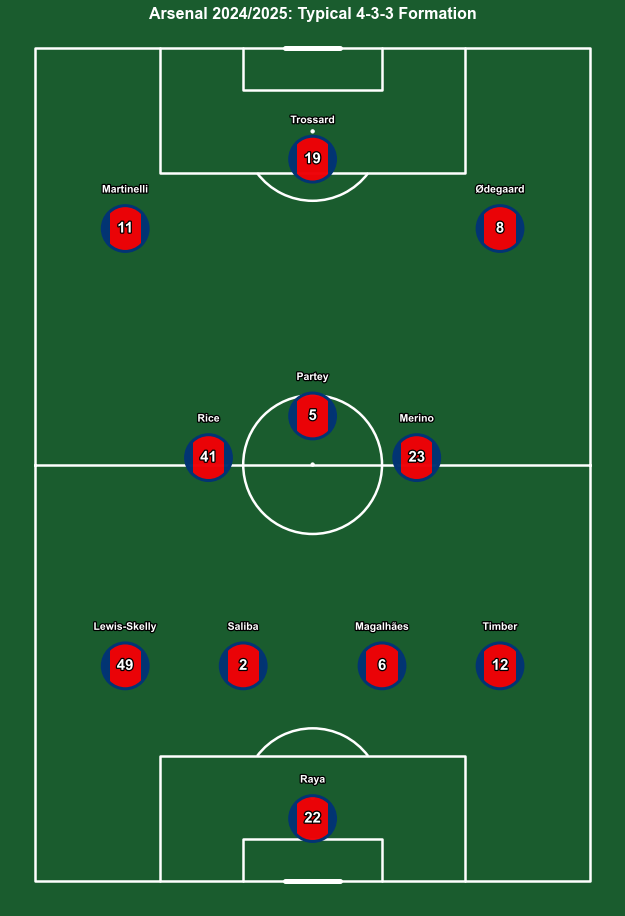

  ✓ Saved: Arsenal_2024_2025_4_3_3_formation.png

Processing 4-4-2...
  XI (with assignment types):
slot             player  jersey_number position_group  formation_starts assignment_type
  GK         David Raya             22             GK                 7  position_match
  LB Riccardo Calafiori             33             LB                 4  position_match
 LCB  Gabriel Magalhães              6             CB                 7  position_match
 LCM      Thomas Partey              5             CM                 7  position_match
  LM Gabriel Martinelli             11             LW                 6  position_match
 LST        Kai Havertz             29             ST                 7  position_match
  RB     Jurriën Timber             12             RB                 5  position_match
 RCB     William Saliba              2             CB                 6  position_match
 RCM        Declan Rice             41             CM                 6  position_match
  RM        Bukayo S

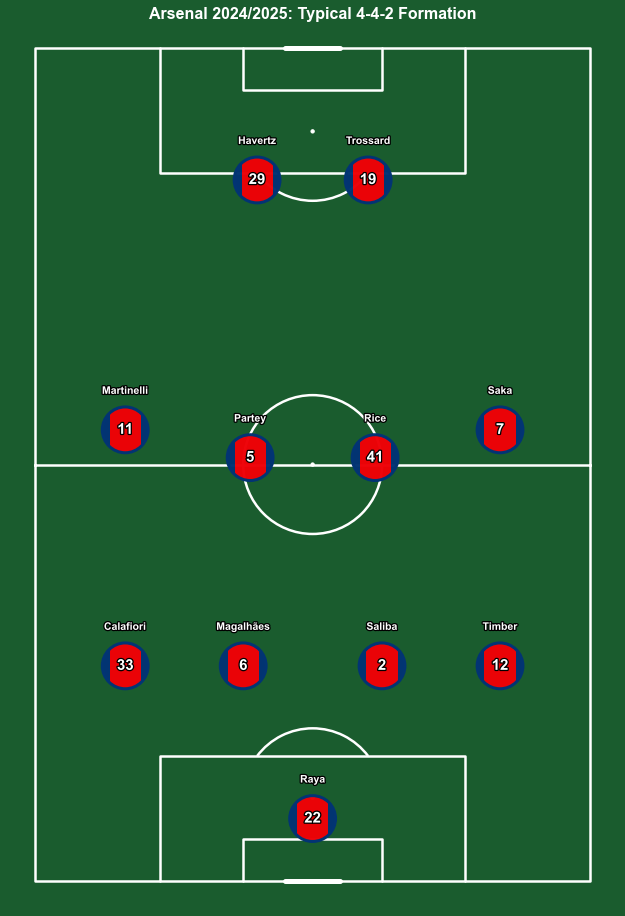

  ✓ Saved: Arsenal_2024_2025_4_4_2_formation.png

Processing 4-2-3-1...
  XI (with assignment types):
slot             player  jersey_number position_group  formation_starts assignment_type
 CAM      Ethan Nwaneri             53             AM                 1  position_match
  GK         David Raya             22             GK                 2  position_match
 LAM Gabriel Martinelli             11             LW                 1  position_match
  LB  Gabriel Magalhães              6             CB                 1  position_match
 LCB       Jakub Kiwior             15             CB                 1  position_match
 LDM        Declan Rice             41             CM                 2  position_match
 RAM    Raheem Sterling             30             ST                 2  position_match
  RB      Thomas Partey              5             CM                 2   fallback_fill
 RCB          Ben White              4             RB                 2  position_match
 RDM       Mikel M

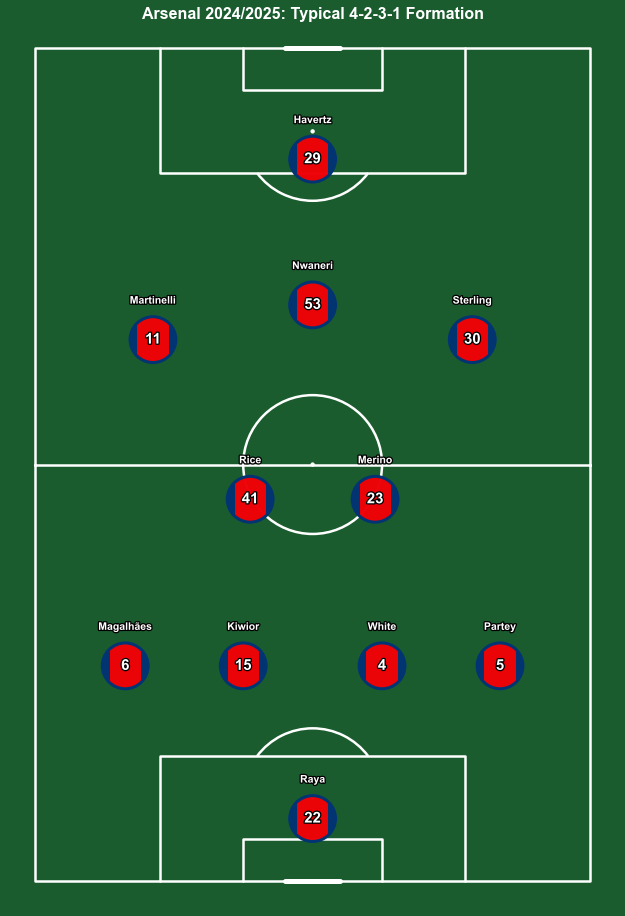

  ✓ Saved: Arsenal_2024_2025_4_2_3_1_formation.png

PIPELINE COMPLETE

✓ Generated formations for Arsenal
✓ Visualized 3 formations
✓ Saved to: /home/vant/Documentos/FOOTBALL_ANALYTICS/MASTER/PROYECT/Data/SEASON_2024_2025/arsenal_2024_2025/outputs/figures/arsenal


In [63]:
# ============================================================================
# SECTION 4: ARSENAL CONFIGURATION & PIPELINE EXECUTION
# ============================================================================

# Prepare lineups data for formation analysis
if 'arsenal_lineups' in dir():
    print("Preparing lineups and player-match data for formation analysis...")
    
    # Standardize column names
    arsenal_lineups_prep = arsenal_lineups.copy()
    arsenal_lineups_prep = arsenal_lineups_prep.rename(columns={
        'Lineup_Section': 'lineup',
        'Formation': 'formation',
        'Player': 'player',
        'Team': 'team',
        'Jersey_Number': 'jersey_number',
        'Match_ID': 'match_id'
    })
    
    # Standardize lineup values
    arsenal_lineups_prep['lineup'] = arsenal_lineups_prep['lineup'].replace({
        'Starter': 'starter', 'Starting': 'starter', 'Bench': 'bench'
    })
    
    print(f"✓ Standardized lineup data: {len(arsenal_lineups_prep)} player-match records")
    print(f"✓ Formations found: {arsenal_lineups_prep['formation'].nunique()}")
    
    # Load player-match data
    player_match_file = PROCESSED_PATH / 'arsenal_player_match_master.csv'
    if player_match_file.exists():
        arsenal_player_match = pd.read_csv(player_match_file)
        print(f"✓ Player-match data: {len(arsenal_player_match)} records")
    else:
        arsenal_player_match = None
        print("⚠️ Player-match data not found - positions will be inferred from lineups only")
    
    # Arsenal-specific position overrides (optional, manually refined)
    arsenal_position_overrides = {
        'Gabriel Martinelli': 'LW',
        'Leandro Trossard': 'RW',
        'Bukayo Saka': 'RW',
        'Kai Havertz': 'ST',
        'Gabriel Jesus': 'ST',
        'Myles Lewis-Skelly': 'LB',
        'Jurriën Timber': 'RB',
        'Riccardo Calafiori': 'LB',
        'Ben White': 'RB',
        'William Saliba': 'CB',
        'Gabriel Magalhães': 'CB',
        'Jakub Kiwior': 'CB',
        'Declan Rice': 'CM',
        'Thomas Partey': 'CM',
        'Martin Ødegaard': 'AM',
        'Mikel Merino': 'CM',
        'Jorginho': 'DM',
        'Ethan Nwaneri': 'AM'
    }
    
    # Arsenal team configuration
    arsenal_config = {
        'name': TEAM_NAME,
        'season': SEASON.replace('_', '/'),
        'colors': {
            'primary': theme['primary'],      # '#EF0107' - Arsenal red
            'secondary': theme['secondary'],  # '#023474' - Arsenal navy
            'pitch': '#1a5c2e'                # Dark green pitch
        },
        'position_overrides': arsenal_position_overrides,
        'output_dir': str(TEAM_FIGURES_PATH),
        'lineups': arsenal_lineups_prep,
        'player_match': arsenal_player_match
    }
    
    print("\n" + "=" * 80)
    print("RUNNING FORMATION VISUALIZATION PIPELINE")
    print("=" * 80)
    
    # Execute pipeline
    all_assigned_xis, formation_freq = generate_team_formation_plots(
        team_name=arsenal_config['name'],
        season=arsenal_config['season'],
        lineups_master=arsenal_config['lineups'],
        player_match_master_full=arsenal_config['player_match'],
        output_dir=arsenal_config['output_dir'],
        team_colors=arsenal_config['colors'],
        position_overrides=arsenal_config['position_overrides'],
        top_n_formations=3,  # Show top 3 formations
        min_formation_starts=1
    )
    
    print("\n" + "=" * 80)
    print("PIPELINE COMPLETE")
    print("=" * 80)
    print(f"\n✓ Generated formations for {arsenal_config['name']}")
    print(f"✓ Visualized {len(all_assigned_xis)} formations")
    print(f"✓ Saved to: {arsenal_config['output_dir']}")
    
else:
    print("⚠️ Arsenal lineups data not loaded. Please run the data loading cell first.")

In [ ]:
# ============================================================================
# SECTION 4a: LOAD ARSENAL LINEUPS DATA (from processed file)
# ============================================================================

print("Loading Arsenal lineups from processed file...")

# Load from processed CSV created by Notebook 01
lineups_file = PROCESSED_PATH / "arsenal_lineups_master.csv"

if lineups_file.exists():
    arsenal_lineups = pd.read_csv(lineups_file)
    print(f"✓ Loaded lineups: {len(arsenal_lineups)} player-match records")
    print(f"✓ Formations found: {arsenal_lineups['Formation'].nunique()}")
    print(f"✓ Columns: {list(arsenal_lineups.columns)}")
else:
    print(f"⚠️ Processed lineups file not found: {lineups_file}")
    print(f"   Make sure Notebook 01 has been executed to create this file.")
    arsenal_lineups = None

Loading Arsenal lineups from match reports...
Found 58 match folders

✓ Aggregated 55 match lineups
✓ Total player-match records: 1136
✓ Columns: ['Match_ID', 'Match_Report_URL', 'Date', 'Competition', 'Round', 'Venue', 'Opponent', 'Result', 'Match_Report_Name', 'Team', 'Formation', 'Lineup_Section', 'Jersey_Number', 'Player']


In [66]:
# ============================================================================
# 13. SAVE NOTEBOOK 02 OUTPUTS
# ============================================================================

print("\n" + "="*100)
print("SAVING NOTEBOOK 02 ANALYSIS OUTPUTS")
print("="*100)

# Define output file paths
analysis_output = PROCESSED_PATH / f"{TEAM_SLUG}_outfield_performance_scored_min30.csv"
robustness_output = PROCESSED_PATH / f"{TEAM_SLUG}_outfield_performance_scored_min60.csv"
player_decline_output = PROCESSED_PATH / f"{TEAM_SLUG}_player_short_rest_decline_summary.csv"

# Save datasets
df_perf_30.to_csv(analysis_output, index=False)
df_perf_60.to_csv(robustness_output, index=False)
player_decline_df.to_csv(player_decline_output, index=False)

print(f"\n✓ Main scored dataset (≥30 min):    {analysis_output.name}")
print(f"  Shape: {df_perf_30.shape} | Columns: {len(df_perf_30.columns)}")

print(f"\n✓ Robustness dataset (≥60 min):     {robustness_output.name}")
print(f"  Shape: {df_perf_60.shape} | Columns: {len(df_perf_60.columns)}")

print(f"\n✓ Player decline summary:           {player_decline_output.name}")
print(f"  Shape: {player_decline_df.shape} | Summary metrics by player")

print(f"\n" + "="*100)
print("NOTEBOOK 02 COMPLETE: Analysis outputs saved to processed/ directory")
print("="*100)
print(f"\nThese outputs are ready for:")
print(f"  • Notebook 03: Predictive modeling (target: player decline probability)")
print(f"  • Further analysis and team strategy discussions")


SAVING NOTEBOOK 02 ANALYSIS OUTPUTS

✓ Main scored dataset (≥30 min):    arsenal_outfield_performance_scored_min30.csv
  Shape: (629, 62) | Columns: 62

✓ Robustness dataset (≥60 min):     arsenal_outfield_performance_scored_min60.csv
  Shape: (535, 61) | Columns: 61

✓ Player decline summary:           arsenal_player_short_rest_decline_summary.csv
  Shape: (19, 7) | Summary metrics by player

NOTEBOOK 02 COMPLETE: Analysis outputs saved to processed/ directory

These outputs are ready for:
  • Notebook 03: Predictive modeling (target: player decline probability)
  • Further analysis and team strategy discussions
